# Backtest temporal tabular score strategies

This notebook evaluates all temporal tabular runs listed in `outputs/tables/temporal_tabular_experiment_comparison.csv` with the same validation/test score-strategy protocol used in `11_train_dl_xgb_and_evaluate_score_strategies.ipynb`.

Each model contributes two saved scores: `classifier = P(top) - P(bottom)` and `er_train`, the class-probability weighted return score saved by the training script.


In [3]:
# Cell 1: Imports, configuration, and paths

from __future__ import annotations

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start] + list(start.parents):
        if (path / "outputs").exists() and (path / "scripts").exists():
            return path
    raise FileNotFoundError("Could not infer repo root. Run this notebook from the repo or notebooks/ folder.")


REPO_ROOT = find_repo_root()
PREDICTION_DIR = REPO_ROOT / "outputs/predictions"
TABLE_DIR = REPO_ROOT / "outputs/tables"
COMPARISON_PATH = TABLE_DIR / "temporal_tabular_experiment_comparison.csv"
BACKTEST_DIR = REPO_ROOT / "outputs/backtests/temporal_tabular_score_strategies"
FIGURE_DIR = BACKTEST_DIR / "figures"
for directory in [TABLE_DIR, BACKTEST_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

KEY_COLUMNS = ["PERMNO", "MthCalDt"]
BASE_COLUMNS = ["PERMNO", "gvkey", "MthCalDt", "split", "target_ret_1m", "target_quintile", "top_bottom_label"]
PROBABILITY_COLUMNS = ["prob_temporal_tabular_bottom", "prob_temporal_tabular_middle", "prob_temporal_tabular_top"]
SCORE_SOURCE_COLUMNS = ["prediction_temporal_tabular_classifier_score", "prediction_temporal_tabular_er_train_score"]
CLASS_LABELS = ["bottom", "middle", "top"]
SELECTION_COST_BPS = 10.0

print(f"Repo root: {REPO_ROOT}")
print(f"Comparison table: {COMPARISON_PATH}")
print(f"Backtest output directory: {BACKTEST_DIR}")


Repo root: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164
Comparison table: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/tables/temporal_tabular_experiment_comparison.csv
Backtest output directory: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/temporal_tabular_score_strategies


In [4]:
# Cell 2: Load temporal tabular experiment registry and prediction artifacts

if not COMPARISON_PATH.exists():
    raise FileNotFoundError(f"Missing temporal tabular comparison table: {COMPARISON_PATH}")

comparison = pd.read_csv(COMPARISON_PATH).drop_duplicates("run_name").copy()
comparison["prediction_path"] = comparison["run_name"].map(lambda run: PREDICTION_DIR / f"{run}_predictions.parquet")
comparison["prediction_exists"] = comparison["prediction_path"].map(Path.exists)
missing = comparison.loc[~comparison["prediction_exists"], ["run_name", "prediction_path"]]
if not missing.empty:
    raise FileNotFoundError("Missing prediction file(s):\n" + missing.to_string(index=False))


def short_run_label(run_name: str) -> str:
    label = run_name.removeprefix("temporal_tabular_")
    label = label.replace("transformer_seed362559", "default_seed362559")
    label = re.sub(r"[^0-9a-zA-Z_]+", "_", label)
    return label.strip("_")


predictions = None
score_columns: dict[str, str] = {}
score_to_run_label: dict[str, str] = {}
run_label_to_name: dict[str, str] = {}
coverage_rows = []

for row in comparison.itertuples(index=False):
    run_name = row.run_name
    run_label = short_run_label(run_name)
    run_label_to_name[run_label] = run_name
    path = Path(row.prediction_path)
    run_df = pd.read_parquet(path)
    run_df["MthCalDt"] = pd.to_datetime(run_df["MthCalDt"], errors="raise")
    run_df["split"] = run_df["split"].astype(str)

    required = BASE_COLUMNS + PROBABILITY_COLUMNS + SCORE_SOURCE_COLUMNS
    missing_cols = [col for col in required if col not in run_df.columns]
    if missing_cols:
        raise ValueError(f"{path.name} is missing required columns: {missing_cols}")
    if run_df.duplicated(KEY_COLUMNS).any():
        raise ValueError(f"{path.name} has duplicate PERMNO-MthCalDt rows.")

    if predictions is None:
        predictions = run_df[BASE_COLUMNS].copy()
    else:
        key_check = predictions[KEY_COLUMNS].merge(run_df[KEY_COLUMNS], on=KEY_COLUMNS, how="outer", indicator=True)
        if not key_check["_merge"].eq("both").all():
            raise ValueError(f"Prediction keys in {path.name} do not match the first loaded temporal run.")

    renamed = run_df[KEY_COLUMNS + PROBABILITY_COLUMNS + SCORE_SOURCE_COLUMNS].rename(
        columns={
            "prob_temporal_tabular_bottom": f"prob_{run_label}_bottom",
            "prob_temporal_tabular_middle": f"prob_{run_label}_middle",
            "prob_temporal_tabular_top": f"prob_{run_label}_top",
            "prediction_temporal_tabular_classifier_score": f"score_{run_label}_classifier",
            "prediction_temporal_tabular_er_train_score": f"score_{run_label}_er_train",
        }
    )
    predictions = predictions.merge(renamed, on=KEY_COLUMNS, how="left", validate="one_to_one")

    for score_type in ["classifier", "er_train"]:
        score_label = f"{run_label}_{score_type}"
        score_columns[score_label] = f"score_{run_label}_{score_type}"
        score_to_run_label[score_label] = run_label

    coverage_rows.append(
        {
            "run_name": run_name,
            "run_label": run_label,
            "rows": len(run_df),
            "first_month": run_df["MthCalDt"].min(),
            "last_month": run_df["MthCalDt"].max(),
            "classifier_nonnull": int(run_df["prediction_temporal_tabular_classifier_score"].notna().sum()),
            "er_train_nonnull": int(run_df["prediction_temporal_tabular_er_train_score"].notna().sum()),
        }
    )

if predictions is None:
    raise ValueError("No prediction files were loaded.")

predictions = predictions.sort_values(["MthCalDt", "PERMNO"]).reset_index(drop=True)
coverage = pd.DataFrame(coverage_rows)
comparison.to_csv(TABLE_DIR / "temporal_tabular_backtest_loaded_runs.csv", index=False)
coverage.to_csv(TABLE_DIR / "temporal_tabular_backtest_prediction_coverage.csv", index=False)
predictions.to_parquet(PREDICTION_DIR / "temporal_tabular_backtest_predictions.parquet", index=False)

display(comparison[["run_name", "architecture_preset", "tabular_branch", "best_epoch", "validation_classifier_rank_ic_mean", "validation_er_train_rank_ic_mean", "test_classifier_rank_ic_mean", "test_er_train_rank_ic_mean", "prediction_path"]])
display(predictions.groupby("split", observed=True).agg(rows=("PERMNO", "size"), first_month=("MthCalDt", "min"), last_month=("MthCalDt", "max"), stocks=("PERMNO", "nunique")))
display(coverage)
print(f"Merged prediction table: {predictions.shape[0]:,} rows x {predictions.shape[1]:,} columns")


,run_name,architecture_preset,tabular_branch,best_epoch,validation_classifier_rank_ic_mean,validation_er_train_rank_ic_mean,test_classifier_rank_ic_mean,test_er_train_rank_ic_mean,prediction_path
0,temporal_tabular_tiny_random,tiny,ft_transformer,13,0.097549,0.079008,0.102822,0.083901,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
1,temporal_tabular_small_random,small,ft_transformer,3,0.093132,0.058306,0.089672,0.048017,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
2,temporal_tabular_small_mlp_branch,small,mlp,3,0.091212,0.050567,0.094774,0.066228,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
3,temporal_tabular_transformer_seed362559,default,ft_transformer,1,0.088519,0.053489,0.101740,0.058755,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
4,temporal_tabular_small_ft_warmstart,small,ft_transformer,2,0.088037,0.050690,0.098577,0.072101,/home/aturin/ML/ML_For_Finance_Project-AxelTur...
5,temporal_tabular_small_mlp_warmstart,small,mlp,1,0.077250,0.041050,0.097488,0.074288,/home/aturin/ML/ML_For_Finance_Project-AxelTur...


,rows,first_month,last_month,stocks
split,,,,
test,868926,2015-12-31,2024-10-31,14523
train,1834902,1989-12-29,2010-11-30,19469
validation,405264,2010-12-31,2015-11-30,9129


,run_name,run_label,rows,first_month,last_month,classifier_nonnull,er_train_nonnull
0,temporal_tabular_tiny_random,tiny_random,3109092,1989-12-29,2024-10-31,3109092,3109092
1,temporal_tabular_small_random,small_random,3109092,1989-12-29,2024-10-31,3109092,3109092
2,temporal_tabular_small_mlp_branch,small_mlp_branch,3109092,1989-12-29,2024-10-31,3109092,3109092
3,temporal_tabular_transformer_seed362559,default_seed362559,3109092,1989-12-29,2024-10-31,3109092,3109092
4,temporal_tabular_small_ft_warmstart,small_ft_warmstart,3109092,1989-12-29,2024-10-31,3109092,3109092
5,temporal_tabular_small_mlp_warmstart,small_mlp_warmstart,3109092,1989-12-29,2024-10-31,3109092,3109092


Merged prediction table: 3,109,092 rows x 37 columns


In [5]:
# Cell 3: Monthly Rank IC diagnostics


def monthly_rank_ic(data: pd.DataFrame, score_col: str, target_col: str = "target_ret_1m", date_col: str = "MthCalDt", split_col: str = "split") -> pd.DataFrame:
    rows = []
    for (split, month), part in data.groupby([split_col, date_col], sort=True, observed=True):
        scores = pd.to_numeric(part[score_col], errors="coerce")
        target = pd.to_numeric(part[target_col], errors="coerce")
        valid = scores.notna() & target.notna()
        if valid.sum() < 5 or scores[valid].nunique() <= 1 or target[valid].nunique() <= 1:
            ic = np.nan
        else:
            ic = scores[valid].corr(target[valid], method="spearman")
        rows.append({"split": split, "month": month, "score_name": score_col, "rank_ic": ic, "n_stocks": int(valid.sum())})
    return pd.DataFrame(rows)


def summarize_rank_ic(monthly_ic: pd.DataFrame) -> pd.DataFrame:
    summary = (
        monthly_ic.dropna(subset=["rank_ic"])
        .groupby(["score_label", "split"], observed=True)["rank_ic"]
        .agg(mean_rank_ic="mean", std_rank_ic="std", months="count")
        .reset_index()
    )
    summary["rank_ic_tstat"] = summary["mean_rank_ic"] / summary["std_rank_ic"] * np.sqrt(summary["months"])
    return summary.sort_values(["split", "mean_rank_ic"], ascending=[True, False])


monthly_ic_frames = []
for label, col in score_columns.items():
    tmp = monthly_rank_ic(predictions, col)
    tmp["score_label"] = label
    tmp["run_label"] = score_to_run_label[label]
    tmp["run_name"] = tmp["run_label"].map(run_label_to_name)
    tmp["score_type"] = "er_train" if label.endswith("_er_train") else "classifier"
    monthly_ic_frames.append(tmp)

monthly_ic_all = pd.concat(monthly_ic_frames, ignore_index=True)
rank_ic_summary = summarize_rank_ic(monthly_ic_all)
rank_ic_summary["run_label"] = rank_ic_summary["score_label"].map(score_to_run_label)
rank_ic_summary["run_name"] = rank_ic_summary["run_label"].map(run_label_to_name)
rank_ic_summary["score_type"] = np.where(rank_ic_summary["score_label"].str.endswith("_er_train"), "er_train", "classifier")

monthly_ic_all.to_csv(BACKTEST_DIR / "temporal_tabular_score_monthly_rank_ic.csv", index=False)
rank_ic_summary.to_csv(BACKTEST_DIR / "temporal_tabular_score_rank_ic_summary.csv", index=False)
validation_rank_ic = rank_ic_summary.loc[rank_ic_summary["split"].eq("validation")].sort_values("mean_rank_ic", ascending=False).reset_index(drop=True)
validation_rank_ic.to_csv(BACKTEST_DIR / "validation_temporal_tabular_score_rank_ic_ranking.csv", index=False)
display(validation_rank_ic)


,score_label,split,mean_rank_ic,std_rank_ic,months,rank_ic_tstat,run_label,run_name,score_type
0,tiny_random_classifier,validation,0.097549,0.100286,60,7.534537,tiny_random,temporal_tabular_tiny_random,classifier
1,small_random_classifier,validation,0.093132,0.110921,60,6.503703,small_random,temporal_tabular_small_random,classifier
2,small_mlp_branch_classifier,validation,0.091212,0.097040,60,7.280740,small_mlp_branch,temporal_tabular_small_mlp_branch,classifier
3,default_seed362559_classifier,validation,0.088519,0.099705,60,6.876927,default_seed362559,temporal_tabular_transformer_seed362559,classifier
4,small_ft_warmstart_classifier,validation,0.088037,0.081325,60,8.385273,small_ft_warmstart,temporal_tabular_small_ft_warmstart,classifier
5,tiny_random_er_train,validation,0.079008,0.083235,60,7.352566,tiny_random,temporal_tabular_tiny_random,er_train
6,small_mlp_warmstart_classifier,validation,0.077250,0.089721,60,6.669270,small_mlp_warmstart,temporal_tabular_small_mlp_warmstart,classifier
7,small_random_er_train,validation,0.058306,0.087317,60,5.172353,small_random,temporal_tabular_small_random,er_train
8,default_seed362559_er_train,validation,0.053489,0.125252,60,3.307935,default_seed362559,temporal_tabular_transformer_seed362559,er_train
9,small_ft_warmstart_er_train,validation,0.050690,0.094274,60,4.164906,small_ft_warmstart,temporal_tabular_small_ft_warmstart,er_train


In [6]:
# Cell 4: Portfolio construction helpers


def make_weights_for_month(part: pd.DataFrame, score_col: str, rule: str, q: float = 0.20, short_exposure: float = 1.0, long_exposure: float = 1.0, sign_gate: bool = False, threshold_gate: bool = False, zero_threshold: float = 0.0) -> pd.Series:
    if sign_gate and threshold_gate:
        raise ValueError("Use either sign_gate or threshold_gate, not both.")
    scores = pd.to_numeric(part[score_col], errors="coerce")
    valid = scores.notna()
    weights = pd.Series(0.0, index=part.index)
    if valid.sum() < 10:
        return weights
    ranks = scores[valid].rank(method="first", pct=True)
    long_idx = ranks[ranks >= 1 - q].index
    short_idx = ranks[ranks <= q].index
    if sign_gate:
        long_idx = long_idx[scores.loc[long_idx] > 0]
        short_idx = short_idx[scores.loc[short_idx] < 0]
    elif threshold_gate:
        long_idx = long_idx[scores.loc[long_idx] > zero_threshold]
        short_idx = short_idx[scores.loc[short_idx] < -zero_threshold]
    if rule == "long_only":
        if len(long_idx) > 0:
            weights.loc[long_idx] = 1.0 / len(long_idx)
        return weights
    if rule == "long_short":
        le, se = long_exposure, short_exposure
    elif rule == "gross_normalized_long_short":
        le, se = 0.5, 0.5
    elif rule == "long_short_130_30":
        le, se = 1.3, 0.3
    else:
        raise ValueError(f"Unknown rule: {rule}")
    if len(long_idx) > 0:
        weights.loc[long_idx] = le / len(long_idx)
    if len(short_idx) > 0:
        weights.loc[short_idx] = -se / len(short_idx)
    return weights


def build_portfolio_returns(data: pd.DataFrame, score_label: str, score_col: str, rule: str, q: float = 0.20, sign_gate: bool = False, threshold_gate: bool = False, zero_threshold: float = 0.0, one_way_cost_bps: float = 0.0, target_col: str = "target_ret_1m", date_col: str = "MthCalDt", split_col: str = "split") -> pd.DataFrame:
    rows = []
    previous_weights_by_split: dict[str, pd.Series] = {}
    data = data.sort_values([split_col, date_col, "PERMNO"]).copy()
    for (split, month), part in data.groupby([split_col, date_col], sort=True, observed=True):
        weights = make_weights_for_month(part, score_col=score_col, rule=rule, q=q, sign_gate=sign_gate, threshold_gate=threshold_gate, zero_threshold=zero_threshold)
        returns = pd.to_numeric(part[target_col], errors="coerce").fillna(0.0)
        gross_return = float((weights * returns).sum())
        long_weight = weights.clip(lower=0).sum()
        short_weight = -weights.clip(upper=0).sum()
        gross_exposure = weights.abs().sum()
        net_exposure = weights.sum()
        long_return = float((weights.clip(lower=0) * returns).sum() / long_weight) if long_weight > 0 else np.nan
        short_leg_contribution = float((weights.clip(upper=0) * returns).sum()) if short_weight > 0 else np.nan
        short_leg_return = float(short_leg_contribution / short_weight) if short_weight > 0 else np.nan
        current_weights = pd.Series(weights.values, index=part["PERMNO"].values)
        previous_weights = previous_weights_by_split.get(split)
        if previous_weights is None:
            turnover = float(current_weights.abs().sum())
        else:
            aligned = pd.concat([previous_weights.rename("prev"), current_weights.rename("curr")], axis=1).fillna(0.0)
            turnover = float((aligned["curr"] - aligned["prev"]).abs().sum())
        cost = (one_way_cost_bps / 10_000.0) * turnover
        rows.append({"split": split, "month": month, "score_label": score_label, "score_col": score_col, "rule": rule, "q": q, "sign_gate": sign_gate, "threshold_gate": threshold_gate, "zero_threshold": zero_threshold, "one_way_cost_bps": one_way_cost_bps, "gross_return": gross_return, "turnover": turnover, "trading_cost": cost, "net_return": gross_return - cost, "long_weight": float(long_weight), "short_weight": float(short_weight), "gross_exposure": float(gross_exposure), "net_exposure": float(net_exposure), "long_leg_return": long_return, "short_leg_return": short_leg_return, "short_leg_contribution": short_leg_contribution, "n_long": int((weights > 0).sum()), "n_short": int((weights < 0).sum())})
        previous_weights_by_split[split] = current_weights
    return pd.DataFrame(rows)


In [7]:
# Cell 5: Portfolio performance summary helpers


def max_drawdown(returns: pd.Series) -> float:
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    return float((wealth / wealth.cummax() - 1.0).min())


def annualized_return(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0:
        return np.nan
    total = (1.0 + monthly_returns).prod()
    if total <= 0:
        return np.nan
    years = len(monthly_returns) / 12.0
    return float(total ** (1.0 / years) - 1.0)


def annualized_volatility(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) <= 1:
        return np.nan
    return float(monthly_returns.std() * np.sqrt(12))


def sharpe_ratio(monthly_returns: pd.Series) -> float:
    ann_ret = annualized_return(monthly_returns)
    ann_vol = annualized_volatility(monthly_returns)
    if ann_vol == 0 or pd.isna(ann_vol):
        return np.nan
    return float(ann_ret / ann_vol)


def summarize_portfolios(monthly: pd.DataFrame, return_col: str = "net_return") -> pd.DataFrame:
    rows = []
    group_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]
    for keys, part in monthly.groupby(group_cols, observed=True):
        score_label, rule, q, sign_gate, threshold_gate, zero_threshold, cost_bps, split = keys
        rets = part[return_col]
        run_label = score_to_run_label.get(score_label)
        rows.append({"score_label": score_label, "run_label": run_label, "run_name": run_label_to_name.get(run_label), "score_type": "er_train" if score_label.endswith("_er_train") else "classifier", "rule": rule, "q": q, "sign_gate": sign_gate, "threshold_gate": threshold_gate, "zero_threshold": zero_threshold, "one_way_cost_bps": cost_bps, "split": split, "months": len(part), "annualized_return": annualized_return(rets), "annualized_volatility": annualized_volatility(rets), "sharpe": sharpe_ratio(rets), "max_drawdown": max_drawdown(rets), "mean_monthly_return": rets.mean(), "std_monthly_return": rets.std(), "average_turnover": part["turnover"].mean(), "average_gross_exposure": part["gross_exposure"].mean(), "average_net_exposure": part["net_exposure"].mean(), "average_long_weight": part["long_weight"].mean(), "average_short_weight": part["short_weight"].mean(), "average_n_long": part["n_long"].mean(), "average_n_short": part["n_short"].mean(), "average_long_leg_return": part["long_leg_return"].mean(), "average_short_leg_return": part["short_leg_return"].mean(), "average_short_leg_contribution": part["short_leg_contribution"].mean()})
    return pd.DataFrame(rows)


In [8]:
# Cell 6: Define score and strategy grid, then run validation/test backtests

THRESHOLD_GRID = [0.00, 0.01, 0.02]
strategy_grid = [
    {"rule": "long_only", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "gross_normalized_long_short", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
    {"rule": "long_short_130_30", "q": 0.20, "sign_gate": False, "threshold_gate": False, "zero_threshold": 0.0},
]
for tau in THRESHOLD_GRID:
    strategy_grid.append({"rule": "long_short", "q": 0.20, "sign_gate": False, "threshold_gate": True, "zero_threshold": tau})

cost_grid_bps = [0.0, 10.0, 25.0]
candidate_score_labels = list(score_columns)
print("Candidate score labels used in the strategy grid:")
print("\n".join(candidate_score_labels))

portfolio_frames = []
work_small = predictions.loc[predictions["split"].isin(["validation", "test"])].copy()
for score_label in candidate_score_labels:
    score_col = score_columns[score_label]
    for strategy in strategy_grid:
        bt_base = build_portfolio_returns(work_small, score_label=score_label, score_col=score_col, rule=strategy["rule"], q=strategy["q"], sign_gate=strategy["sign_gate"], threshold_gate=strategy["threshold_gate"], zero_threshold=strategy["zero_threshold"], one_way_cost_bps=0.0)
        for cost_bps in cost_grid_bps:
            bt = bt_base.copy()
            bt["one_way_cost_bps"] = cost_bps
            bt["trading_cost"] = (cost_bps / 10_000.0) * bt["turnover"]
            bt["net_return"] = bt["gross_return"] - bt["trading_cost"]
            portfolio_frames.append(bt)

portfolio_monthly = pd.concat(portfolio_frames, ignore_index=True)
portfolio_summary_net = summarize_portfolios(portfolio_monthly, return_col="net_return")
portfolio_summary_gross = summarize_portfolios(portfolio_monthly, return_col="gross_return").rename(columns={"annualized_return": "gross_annualized_return", "annualized_volatility": "gross_annualized_volatility", "sharpe": "gross_sharpe", "max_drawdown": "gross_max_drawdown", "mean_monthly_return": "gross_mean_monthly_return", "std_monthly_return": "gross_std_monthly_return"})
merge_cols = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps", "split"]
portfolio_summary = portfolio_summary_net.merge(portfolio_summary_gross[merge_cols + ["gross_annualized_return", "gross_annualized_volatility", "gross_sharpe", "gross_max_drawdown", "gross_mean_monthly_return", "gross_std_monthly_return"]], on=merge_cols, how="left")
portfolio_monthly.to_csv(BACKTEST_DIR / "temporal_tabular_score_strategy_monthly_returns.csv", index=False)
portfolio_summary.to_csv(BACKTEST_DIR / "temporal_tabular_score_strategy_performance_summary.csv", index=False)
display(portfolio_summary.head())


Candidate score labels used in the strategy grid:
tiny_random_classifier
tiny_random_er_train
small_random_classifier
small_random_er_train
small_mlp_branch_classifier
small_mlp_branch_er_train
default_seed362559_classifier
default_seed362559_er_train
small_ft_warmstart_classifier
small_ft_warmstart_er_train
small_mlp_warmstart_classifier
small_mlp_warmstart_er_train


,score_label,run_label,run_name,score_type,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_long_weight,average_short_weight,average_n_long,average_n_short,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,test,107,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699,0.331840,1.0,-5.421011e-19,0.5,0.5,1624.757009,1623.757009,0.011844,0.001044,0.000522,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699
1,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,0.0,validation,60,0.072454,0.061093,1.185973,-0.075871,0.005999,0.017636,0.354932,1.0,-4.221160e-18,0.5,0.5,1351.516667,1350.516667,0.009820,0.002178,0.001089,0.072454,0.061093,1.185973,-0.075871,0.005999,0.017636
2,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,test,107,0.070217,0.102931,0.682181,-0.291595,0.006112,0.029714,0.331840,1.0,-5.421011e-19,0.5,0.5,1624.757009,1623.757009,0.011844,0.001044,0.000522,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699
3,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,10.0,validation,60,0.067917,0.061158,1.110509,-0.078424,0.005644,0.017655,0.354932,1.0,-4.221160e-18,0.5,0.5,1351.516667,1350.516667,0.009820,0.002178,0.001089,0.072454,0.061093,1.185973,-0.075871,0.005999,0.017636
4,default_seed362559_classifier,default_seed362559,temporal_tabular_transformer_seed362559,classifier,gross_normalized_long_short,0.2,False,False,0.0,25.0,test,107,0.063867,0.103007,0.620023,-0.298542,0.005614,0.029736,0.331840,1.0,-5.421011e-19,0.5,0.5,1624.757009,1623.757009,0.011844,0.001044,0.000522,0.074470,0.102882,0.723843,-0.286928,0.006444,0.029699


In [9]:
# Cell 7: Validation rankings by annualized return with composite score

VALIDATION_RANKING_COLUMNS = ["score_label", "run_name", "score_type", "rule", "q", "threshold_gate", "zero_threshold", "one_way_cost_bps", "validation_composite_score", "validation_rank_ic", "validation_rank_ic_tstat", "validation_net_sharpe", "validation_net_annualized_return", "validation_net_annualized_volatility", "average_turnover", "eligible_for_selection", "average_n_long", "average_n_short", "average_gross_exposure", "average_long_leg_return", "average_short_leg_return", "average_short_leg_contribution", "max_drawdown"]


def build_validation_selection_ranking(portfolio_summary: pd.DataFrame, validation_rank_ic: pd.DataFrame) -> pd.DataFrame:
    rank_ic_lookup = validation_rank_ic[["score_label", "mean_rank_ic", "rank_ic_tstat"]].rename(columns={"mean_rank_ic": "validation_rank_ic", "rank_ic_tstat": "validation_rank_ic_tstat"})
    ranking = portfolio_summary.loc[portfolio_summary["split"].eq("validation")].merge(rank_ic_lookup, on="score_label", how="left", validate="many_to_one").copy()
    ranking["validation_net_sharpe"] = ranking["sharpe"]
    ranking["validation_net_annualized_return"] = ranking["annualized_return"]
    ranking["validation_net_annualized_volatility"] = ranking["annualized_volatility"]
    ranking["eligible_for_selection"] = ranking["validation_rank_ic"].notna() & ranking["validation_net_sharpe"].notna() & ranking["validation_net_annualized_return"].notna() & ranking["validation_net_annualized_volatility"].notna() & ranking["average_turnover"].notna() & ranking["average_turnover"].gt(0) & ranking["average_gross_exposure"].gt(0) & ranking["validation_net_annualized_volatility"].gt(0)
    ranking["validation_composite_score"] = ranking["validation_rank_ic"] + ranking["validation_net_sharpe"] + ranking["validation_net_annualized_return"] - ranking["average_turnover"] - ranking["validation_net_annualized_volatility"]
    ranking.loc[~ranking["eligible_for_selection"], "validation_composite_score"] = -np.inf
    return ranking.sort_values(["one_way_cost_bps", "eligible_for_selection", "validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"], ascending=[True, False, False, False, False]).reset_index(drop=True)


validation_portfolios = build_validation_selection_ranking(portfolio_summary, validation_rank_ic)
validation_portfolios.to_csv(BACKTEST_DIR / "validation_temporal_tabular_score_strategy_ranking.csv", index=False)
validation_rankings_by_cost = {}
for cost in cost_grid_bps:
    ranking = validation_portfolios.loc[validation_portfolios["one_way_cost_bps"].eq(cost)].reset_index(drop=True)
    validation_rankings_by_cost[cost] = ranking
    ranking.to_csv(BACKTEST_DIR / f"validation_temporal_tabular_score_strategy_ranking_{int(cost)}bps.csv", index=False)
    print(f"Validation ranking by net annualized return at {cost:.0f} bps")
    display(ranking[VALIDATION_RANKING_COLUMNS].head(30))


Validation ranking by net annualized return at 0 bps


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,0.0,2.689663,0.050690,4.164906,2.964651,1.723218,0.581255,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.543462
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,0.0,1.351655,0.041050,2.531480,2.347719,1.619898,0.689988,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.528000
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,0.0,0.262116,0.058306,5.172353,1.379042,0.748611,0.542849,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.581122
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,0.0,-0.337126,0.050567,3.635593,1.019245,0.368150,0.361199,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.291155
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,0.0,0.417552,0.058306,5.172353,1.257509,0.308247,0.245125,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.208097
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,0.0,0.144685,0.053489,3.307935,1.359546,0.304766,0.224167,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.212357
6,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,0.0,-0.995613,0.053489,3.307935,0.866203,0.291842,0.336921,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.351469
7,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,0.0,0.607442,0.050690,4.164906,1.460960,0.290883,0.199104,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.165099
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,0.0,0.287632,0.053489,3.307935,1.369072,0.249527,0.182260,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.241024
9,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.00,0.0,-0.674363,0.041050,2.531480,0.988544,0.237449,0.240201,1.701206,True,1351.516667,131.650000,2.000000,0.008700,0.011694,0.011694,-0.248226


Validation ranking by net annualized return at 10 bps


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,10.0,2.571715,0.050690,4.164906,2.890362,1.679304,0.581001,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.544179
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,10.0,1.210237,0.041050,2.531480,2.264002,1.562247,0.690038,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.532274
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,10.0,0.182977,0.058306,5.172353,1.327759,0.720702,0.542795,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.582481
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,10.0,-0.421623,0.050567,3.635593,0.957166,0.345625,0.361092,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.296060
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,10.0,0.341598,0.058306,5.172353,1.196483,0.293478,0.245284,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.211179
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,10.0,0.032800,0.053489,3.307935,1.268160,0.284219,0.224119,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.216196
6,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,10.0,0.517017,0.050690,4.164906,1.385558,0.275840,0.199082,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.167484
7,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,10.0,-1.105937,0.053489,3.307935,0.783621,0.263726,0.336547,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.353686
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,10.0,0.175168,0.053489,3.307935,1.273989,0.231958,0.182072,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.247628
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short,0.2,True,0.00,10.0,0.317613,0.079008,7.352566,1.095020,0.223452,0.204062,0.875804,True,1351.516667,334.183333,2.000000,0.010761,0.008810,0.008810,-0.202454


Validation ranking by net annualized return at 25 bps


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,25.0,2.397922,0.050690,4.164906,2.780858,1.614641,0.580627,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.545254
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,25.0,1.003348,0.041050,2.531480,2.141526,1.477920,0.690125,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.540475
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,25.0,0.066375,0.058306,5.172353,1.252193,0.679593,0.542723,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.584518
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,25.0,-0.546078,0.050567,3.635593,0.865714,0.312470,0.360939,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.303368
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,25.0,0.229231,0.058306,5.172353,1.106228,0.271609,0.245527,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.215785
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,25.0,-0.132253,0.053489,3.307935,1.133331,0.253947,0.224072,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.221938
6,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,25.0,0.383109,0.050690,4.164906,1.273888,0.253574,0.199055,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.171051
7,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,25.0,-1.267717,0.053489,3.307935,0.662444,0.222591,0.336014,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.370870
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,25.0,0.008638,0.053489,3.307935,1.133138,0.206022,0.181815,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.257446
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short,0.2,True,0.00,25.0,0.205150,0.079008,7.352566,1.001616,0.204551,0.204221,0.875804,True,1351.516667,334.183333,2.000000,0.010761,0.008810,0.008810,-0.210677


best_rank_ic: tiny_random_classifier


,bottom,middle,top
bottom,13057,68025,0
middle,6858,236261,0
top,8659,72404,0


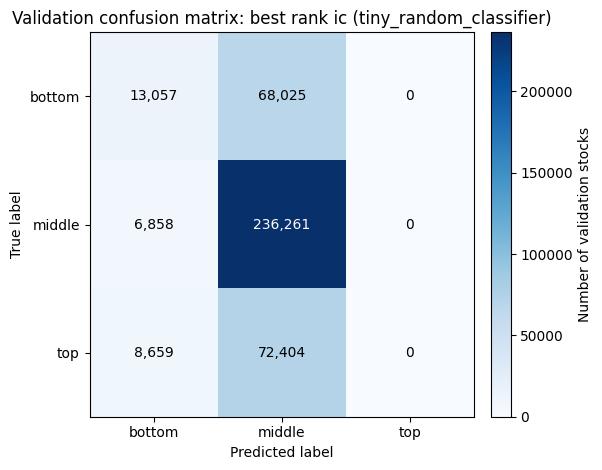

best_annualized_return: small_ft_warmstart_er_train


,bottom,middle,top
bottom,7774,73308,0
middle,3832,239287,0
top,4955,76108,0


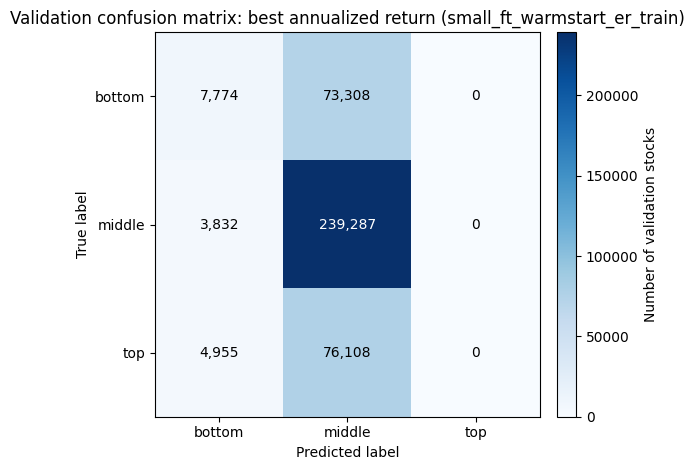

,score_label,run_label,run_name,validation_rows,accuracy,selection
0,tiny_random_classifier,tiny_random,temporal_tabular_tiny_random,405264,0.615199,best_rank_ic
1,small_ft_warmstart_er_train,small_ft_warmstart,temporal_tabular_small_ft_warmstart,405264,0.609630,best_annualized_return


In [10]:
# Cell 8: Validation confusion matrices for best selected score families


def validation_confusion_matrix_for_score(score_label: str) -> tuple[pd.DataFrame, pd.Series]:
    run_label = score_to_run_label[score_label]
    prob_cols = [f"prob_{run_label}_bottom", f"prob_{run_label}_middle", f"prob_{run_label}_top"]
    validation = predictions.loc[predictions["split"].eq("validation"), ["top_bottom_label"] + prob_cols].dropna().copy()
    validation["predicted_label"] = np.argmax(validation[prob_cols].to_numpy(dtype="float64"), axis=1)
    matrix = pd.crosstab(validation["top_bottom_label"], validation["predicted_label"], rownames=["True label"], colnames=["Predicted label"], dropna=False).reindex(index=[0, 1, 2], columns=[0, 1, 2], fill_value=0)
    matrix.index = CLASS_LABELS
    matrix.columns = CLASS_LABELS
    total = matrix.to_numpy().sum()
    summary = pd.Series({"score_label": score_label, "run_label": run_label, "run_name": run_label_to_name.get(run_label), "validation_rows": int(total), "accuracy": float(np.trace(matrix.to_numpy()) / total) if total else np.nan})
    return matrix, summary


def plot_confusion_heatmap(matrix: pd.DataFrame, title: str, path: Path | None = None) -> None:
    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    values = matrix.to_numpy(dtype="float64")
    image = ax.imshow(values, cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Number of validation stocks")
    ax.set_xticks(np.arange(len(CLASS_LABELS)))
    ax.set_yticks(np.arange(len(CLASS_LABELS)))
    ax.set_xticklabels(CLASS_LABELS)
    ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    threshold = values.max() / 2 if values.size and values.max() > 0 else 0
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            color = "white" if values[row, col] > threshold else "black"
            ax.text(col, row, f"{int(values[row, col]):,}", ha="center", va="center", color=color, fontsize=10)
    fig.tight_layout()
    if path is not None:
        fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


best_rank_ic_label = validation_rank_ic.sort_values("mean_rank_ic", ascending=False).iloc[0]["score_label"]
best_annualized_return_label = validation_portfolios.sort_values(["annualized_return", "sharpe"], ascending=False).iloc[0]["score_label"]
confusion_outputs = []
for selection_name, score_label in [("best_rank_ic", best_rank_ic_label), ("best_annualized_return", best_annualized_return_label)]:
    matrix, summary = validation_confusion_matrix_for_score(score_label)
    summary["selection"] = selection_name
    confusion_outputs.append(summary)
    print(f"{selection_name}: {score_label}")
    display(matrix)
    matrix.to_csv(BACKTEST_DIR / f"validation_confusion_matrix_{selection_name}.csv")
    plot_confusion_heatmap(matrix, f"Validation confusion matrix: {selection_name.replace('_', ' ')} ({score_label})", FIGURE_DIR / f"validation_confusion_matrix_{selection_name}.png")
confusion_matrix_summary = pd.DataFrame(confusion_outputs)
confusion_matrix_summary.to_csv(BACKTEST_DIR / "validation_confusion_matrix_summary.csv", index=False)
display(confusion_matrix_summary)


In [11]:
# Cell 9: Choose the specification using validation only and report matching test rows

SPEC_COLUMNS = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps"]
SELECTION_SORT = ["validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"]
selection_table = validation_portfolios.loc[validation_portfolios["one_way_cost_bps"].eq(SELECTION_COST_BPS) & validation_portfolios["eligible_for_selection"]].sort_values(SELECTION_SORT, ascending=[False, False, False]).reset_index(drop=True)
if selection_table.empty:
    raise ValueError("No eligible validation strategies found.")
selection_table.to_csv(BACKTEST_DIR / "validation_temporal_tabular_selection_table_10bps.csv", index=False)
display(selection_table[VALIDATION_RANKING_COLUMNS].head(30))

chosen_spec = selection_table.iloc[0][SPEC_COLUMNS].to_dict()
pd.DataFrame([chosen_spec]).to_csv(BACKTEST_DIR / "chosen_validation_temporal_tabular_specification.csv", index=False)
chosen_test = portfolio_summary.loc[portfolio_summary["split"].eq("test") & portfolio_summary["score_label"].eq(chosen_spec["score_label"]) & portfolio_summary["rule"].eq(chosen_spec["rule"]) & np.isclose(portfolio_summary["q"].astype(float), float(chosen_spec["q"])) & portfolio_summary["sign_gate"].eq(bool(chosen_spec["sign_gate"])) & portfolio_summary["threshold_gate"].eq(bool(chosen_spec["threshold_gate"])) & np.isclose(portfolio_summary["zero_threshold"].astype(float), float(chosen_spec["zero_threshold"])) & np.isclose(portfolio_summary["one_way_cost_bps"].astype(float), float(chosen_spec["one_way_cost_bps"]))].reset_index(drop=True)
assert len(chosen_test) == 1, "Expected exactly one test row for the chosen specification."
chosen_test.to_csv(BACKTEST_DIR / "test_performance_of_chosen_validation_temporal_tabular_spec.csv", index=False)

top_validation_specs = selection_table.head(10)[SPEC_COLUMNS].copy()
test_selected_specs = top_validation_specs.merge(portfolio_summary.loc[portfolio_summary["split"].eq("test")], on=SPEC_COLUMNS, how="left")
test_selected_specs.to_csv(BACKTEST_DIR / "test_performance_of_top_validation_temporal_tabular_specs.csv", index=False)
print("Chosen validation specification:")
print(chosen_spec)
display(chosen_test)
display(test_selected_specs[SPEC_COLUMNS + ["run_name", "score_type", "annualized_return", "annualized_volatility", "sharpe", "max_drawdown", "average_turnover", "average_gross_exposure", "average_n_long", "average_n_short"]])


,score_label,run_name,score_type,rule,q,threshold_gate,zero_threshold,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.01,10.0,2.571715,0.050690,4.164906,2.890362,1.679304,0.581001,1.467640,True,1351.516667,5.433333,1.916667,0.010186,0.099761,0.099761,-0.544179
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,0.2,True,0.01,10.0,1.210237,0.041050,2.531480,2.264002,1.562247,0.690038,1.967024,True,1351.516667,4.350000,1.833333,0.008700,0.112006,0.112006,-0.532274
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.01,10.0,0.182977,0.058306,5.172353,1.327759,0.720702,0.542795,1.380994,True,1351.516667,15.383333,2.000000,0.011213,0.050141,0.050141,-0.582481
3,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,0.2,True,0.01,10.0,-0.421623,0.050567,3.635593,0.957166,0.345625,0.361092,1.413889,True,1351.516667,20.433333,2.000000,0.010024,0.022013,0.022013,-0.296060
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short,0.2,True,0.00,10.0,0.341598,0.058306,5.172353,1.196483,0.293478,0.245284,0.961385,True,1351.516667,167.283333,2.000000,0.011213,0.013926,0.013926,-0.211179
5,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.01,10.0,0.032800,0.053489,3.307935,1.268160,0.284219,0.224119,1.348949,True,1351.516667,145.983333,1.983333,0.010292,0.014444,0.014444,-0.216196
6,small_ft_warmstart_er_train,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,True,0.00,10.0,0.517017,0.050690,4.164906,1.385558,0.275840,0.199082,0.995988,True,1351.516667,138.916667,2.000000,0.010186,0.012939,0.012939,-0.167484
7,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.02,10.0,-1.105937,0.053489,3.307935,0.783621,0.263726,0.336547,1.870226,True,610.150000,50.033333,1.916667,0.013055,0.014596,0.014596,-0.353686
8,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,0.2,True,0.00,10.0,0.175168,0.053489,3.307935,1.273989,0.231958,0.182072,1.202196,True,1351.516667,387.100000,2.000000,0.010292,0.009846,0.009846,-0.247628
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short,0.2,True,0.00,10.0,0.317613,0.079008,7.352566,1.095020,0.223452,0.204062,0.875804,True,1351.516667,334.183333,2.000000,0.010761,0.008810,0.008810,-0.202454


Chosen validation specification:
{'score_label': 'small_ft_warmstart_er_train', 'rule': 'long_short', 'q': 0.2, 'sign_gate': False, 'threshold_gate': True, 'zero_threshold': 0.01, 'one_way_cost_bps': 10.0}


,score_label,run_label,run_name,score_type,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,split,months,annualized_return,annualized_volatility,sharpe,max_drawdown,mean_monthly_return,std_monthly_return,average_turnover,average_gross_exposure,average_net_exposure,average_long_weight,average_short_weight,average_n_long,average_n_short,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,gross_annualized_return,gross_annualized_volatility,gross_sharpe,gross_max_drawdown,gross_mean_monthly_return,gross_std_monthly_return
0,small_ft_warmstart_er_train,small_ft_warmstart,temporal_tabular_small_ft_warmstart,er_train,long_short,0.2,False,True,0.01,10.0,test,107,0.747019,0.536715,1.391836,-0.92319,0.063719,0.154936,1.37787,2.0,2.075994e-17,1.0,1.0,1624.757009,34.205607,0.01137,0.053727,0.053727,0.775226,0.536905,1.443879,-0.921159,0.065097,0.154991


,score_label,rule,q,sign_gate,threshold_gate,zero_threshold,one_way_cost_bps,run_name,score_type,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover,average_gross_exposure,average_n_long,average_n_short
0,small_ft_warmstart_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_ft_warmstart,er_train,0.747019,0.536715,1.391836,-0.923190,1.377870,2.000000,1624.757009,34.205607
1,small_mlp_warmstart_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_mlp_warmstart,er_train,1.469412,0.448286,3.277844,-0.256100,2.079685,1.934579,1624.757009,42.084112
2,small_random_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_random,er_train,0.317986,0.563872,0.563934,-0.852873,1.235219,2.000000,1624.757009,42.457944
3,small_mlp_branch_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_small_mlp_branch,er_train,0.483770,0.372570,1.298469,-0.712836,1.175091,2.000000,1624.757009,80.046729
4,small_random_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_small_random,er_train,0.202033,0.356194,0.567200,-0.757416,0.906366,2.000000,1624.757009,303.897196
5,default_seed362559_er_train,long_short,0.2,False,True,0.01,10.0,temporal_tabular_transformer_seed362559,er_train,0.352322,0.266217,1.323440,-0.442171,1.350368,2.000000,1624.757009,263.644860
6,small_ft_warmstart_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_small_ft_warmstart,er_train,0.207511,0.304063,0.682462,-0.680170,0.942793,2.000000,1624.757009,383.177570
7,default_seed362559_er_train,long_short,0.2,False,True,0.02,10.0,temporal_tabular_transformer_seed362559,er_train,0.487991,0.417597,1.168569,-0.547501,2.320743,1.981308,425.775701,88.112150
8,default_seed362559_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_transformer_seed362559,er_train,0.262319,0.221059,1.186648,-0.479407,1.126496,2.000000,1624.757009,639.028037
9,tiny_random_er_train,long_short,0.2,False,True,0.00,10.0,temporal_tabular_tiny_random,er_train,0.155682,0.309792,0.502539,-0.735432,0.759476,2.000000,1624.757009,593.822430


In [12]:
# Cell 10: Fixed-rule model comparison at 10 bps

FIXED_RULE = "gross_normalized_long_short"
FIXED_COST_BPS = 10.0
fixed_rule_table = portfolio_summary.loc[portfolio_summary["rule"].eq(FIXED_RULE) & portfolio_summary["one_way_cost_bps"].eq(FIXED_COST_BPS) & portfolio_summary["threshold_gate"].eq(False)].merge(rank_ic_summary[["score_label", "split", "mean_rank_ic", "rank_ic_tstat"]], on=["score_label", "split"], how="left")
fixed_rule_table = fixed_rule_table.sort_values(["split", "score_type", "sharpe"], ascending=[True, True, False])
fixed_rule_table.to_csv(BACKTEST_DIR / "temporal_tabular_fixed_rule_model_comparison.csv", index=False)
display(fixed_rule_table[["split", "run_name", "score_label", "score_type", "mean_rank_ic", "rank_ic_tstat", "annualized_return", "annualized_volatility", "sharpe", "max_drawdown", "average_turnover", "average_gross_exposure"]])


,split,run_name,score_label,score_type,mean_rank_ic,rank_ic_tstat,annualized_return,annualized_volatility,sharpe,max_drawdown,average_turnover,average_gross_exposure
0,test,temporal_tabular_transformer_seed362559,default_seed362559_classifier,classifier,0.101740,8.652338,0.070217,0.102931,0.682181,-0.291595,0.331840,1.0
12,test,temporal_tabular_small_mlp_warmstart,small_mlp_warmstart_classifier,classifier,0.097488,8.843133,0.055200,0.104622,0.527613,-0.327739,0.384703,1.0
8,test,temporal_tabular_small_mlp_branch,small_mlp_branch_classifier,classifier,0.094774,7.892902,0.053693,0.112172,0.478667,-0.362316,0.290904,1.0
4,test,temporal_tabular_small_ft_warmstart,small_ft_warmstart_classifier,classifier,0.098577,9.236803,0.044017,0.107881,0.408016,-0.365745,0.201282,1.0
16,test,temporal_tabular_small_random,small_random_classifier,classifier,0.089672,7.052654,0.047703,0.117872,0.404704,-0.387556,0.185395,1.0
20,test,temporal_tabular_tiny_random,tiny_random_classifier,classifier,0.102822,8.253603,0.047948,0.119314,0.401861,-0.404736,0.195455,1.0
2,test,temporal_tabular_transformer_seed362559,default_seed362559_er_train,er_train,0.058755,5.481687,0.091804,0.066683,1.376723,-0.080322,0.469323,1.0
14,test,temporal_tabular_small_mlp_warmstart,small_mlp_warmstart_er_train,er_train,0.074288,6.905043,0.074422,0.079527,0.935808,-0.174226,0.552674,1.0
10,test,temporal_tabular_small_mlp_branch,small_mlp_branch_er_train,er_train,0.066228,6.872710,0.068412,0.073653,0.928844,-0.196553,0.439313,1.0
6,test,temporal_tabular_small_ft_warmstart,small_ft_warmstart_er_train,er_train,0.072101,7.367019,0.064831,0.072815,0.890361,-0.210918,0.239341,1.0


,tiny_random_classifier,tiny_random_er_train,small_random_classifier,small_random_er_train,small_mlp_branch_classifier,small_mlp_branch_er_train,default_seed362559_classifier,default_seed362559_er_train,small_ft_warmstart_classifier,small_ft_warmstart_er_train,small_mlp_warmstart_classifier,small_mlp_warmstart_er_train
tiny_random_classifier,1.000000,0.830316,0.922797,0.592743,0.809595,0.440362,0.787175,0.531497,0.864486,0.461447,0.638365,0.315302
tiny_random_er_train,0.830316,1.000000,0.800389,0.851541,0.702007,0.728584,0.650569,0.723648,0.738885,0.779473,0.724290,0.642174
small_random_classifier,0.922797,0.800389,1.000000,0.723812,0.856449,0.539840,0.806379,0.598623,0.822551,0.511093,0.709923,0.412997
small_random_er_train,0.592743,0.851541,0.723812,1.000000,0.591999,0.826364,0.519200,0.764594,0.532752,0.789836,0.686600,0.757109
small_mlp_branch_classifier,0.809595,0.702007,0.856449,0.591999,1.000000,0.681419,0.830047,0.617996,0.745554,0.474084,0.767961,0.476030
small_mlp_branch_er_train,0.440362,0.728584,0.539840,0.826364,0.681419,1.000000,0.497785,0.766887,0.413521,0.739686,0.713234,0.821953
default_seed362559_classifier,0.787175,0.650569,0.806379,0.519200,0.830047,0.497785,1.000000,0.756099,0.712949,0.395517,0.716354,0.422252
default_seed362559_er_train,0.531497,0.723648,0.598623,0.764594,0.617996,0.766887,0.756099,1.000000,0.489305,0.637181,0.699210,0.731834
small_ft_warmstart_classifier,0.864486,0.738885,0.822551,0.532752,0.745554,0.413521,0.712949,0.489305,1.000000,0.618859,0.610965,0.313262
small_ft_warmstart_er_train,0.461447,0.779473,0.511093,0.789836,0.474084,0.739686,0.395517,0.637181,0.618859,1.000000,0.615798,0.706686


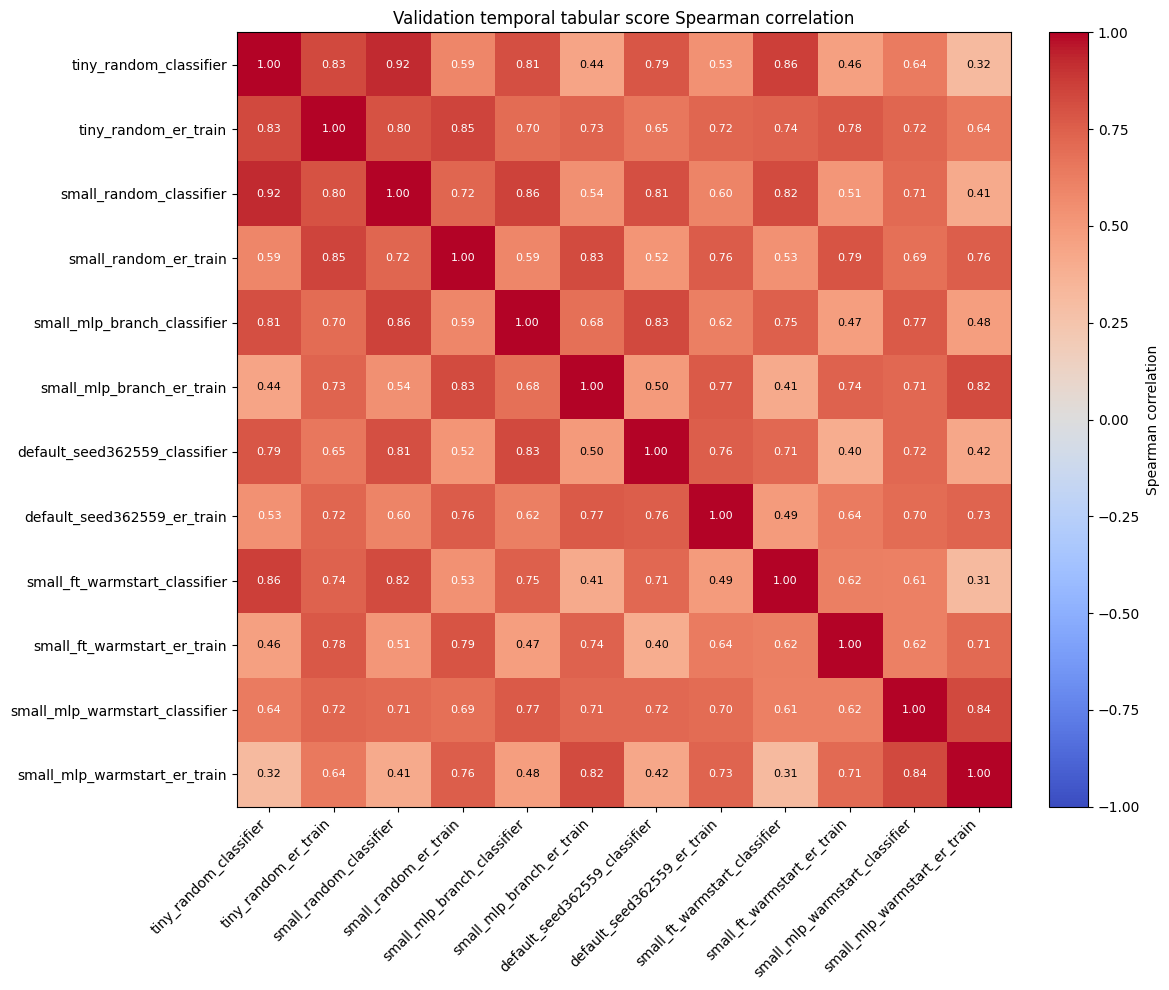

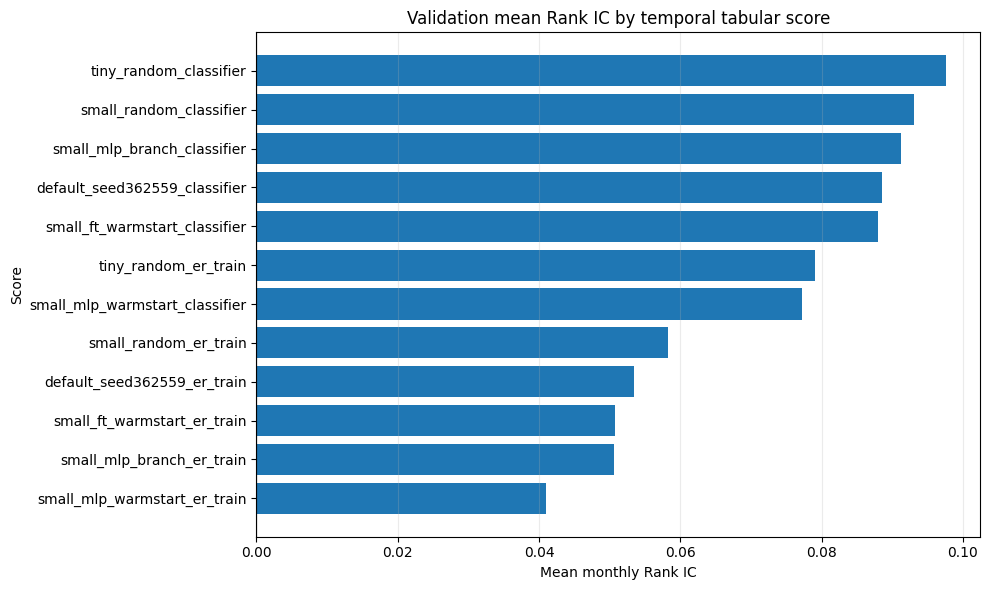

In [13]:
# Cell 11: Validation score correlations and Rank IC chart


def score_correlation_table(data: pd.DataFrame, score_columns: dict[str, str], split: str = "validation") -> pd.DataFrame:
    cols = [col for col in score_columns.values() if col in data.columns]
    labels = {v: k for k, v in score_columns.items()}
    corr = data.loc[data["split"].eq(split), cols].corr(method="spearman")
    return corr.rename(index=labels, columns=labels)


validation_score_corr = score_correlation_table(predictions, score_columns, split="validation")
validation_score_corr.to_csv(BACKTEST_DIR / "validation_temporal_tabular_score_spearman_correlation.csv")
display(validation_score_corr)

if not validation_score_corr.empty:
    fig, ax = plt.subplots(figsize=(12, 10))
    values = validation_score_corr.to_numpy(dtype=float)
    image = ax.imshow(values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(validation_score_corr.columns)))
    ax.set_yticks(range(len(validation_score_corr.index)))
    ax.set_xticklabels(validation_score_corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(validation_score_corr.index)
    ax.set_title("Validation temporal tabular score Spearman correlation")
    for i in range(validation_score_corr.shape[0]):
        for j in range(validation_score_corr.shape[1]):
            value = values[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if abs(value) > 0.5 else "black", fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Spearman correlation")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "validation_temporal_tabular_score_spearman_correlation_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()

rank_ic_plot = validation_rank_ic.sort_values("mean_rank_ic", ascending=True)
fig, ax = plt.subplots(figsize=(10, max(6, 0.35 * len(rank_ic_plot))))
ax.barh(rank_ic_plot["score_label"], rank_ic_plot["mean_rank_ic"])
ax.axvline(0, linewidth=0.8, color="black")
ax.set_title("Validation mean Rank IC by temporal tabular score")
ax.set_xlabel("Mean monthly Rank IC")
ax.set_ylabel("Score")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_temporal_tabular_score_rank_ic_bar_chart.png", dpi=160, bbox_inches="tight")
plt.show()


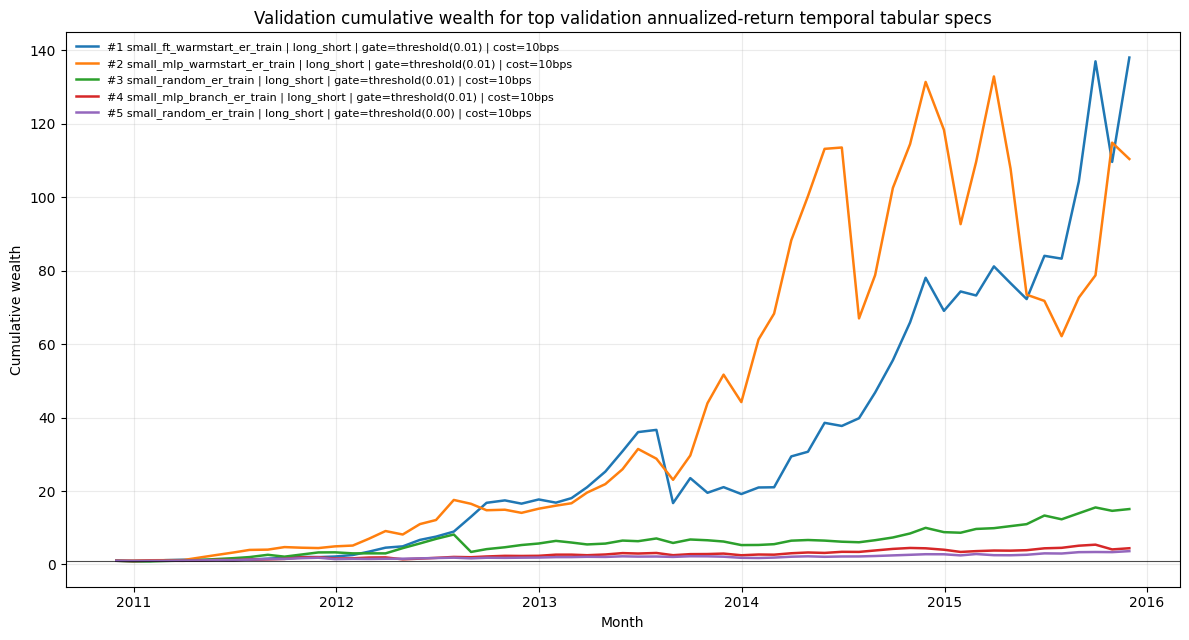

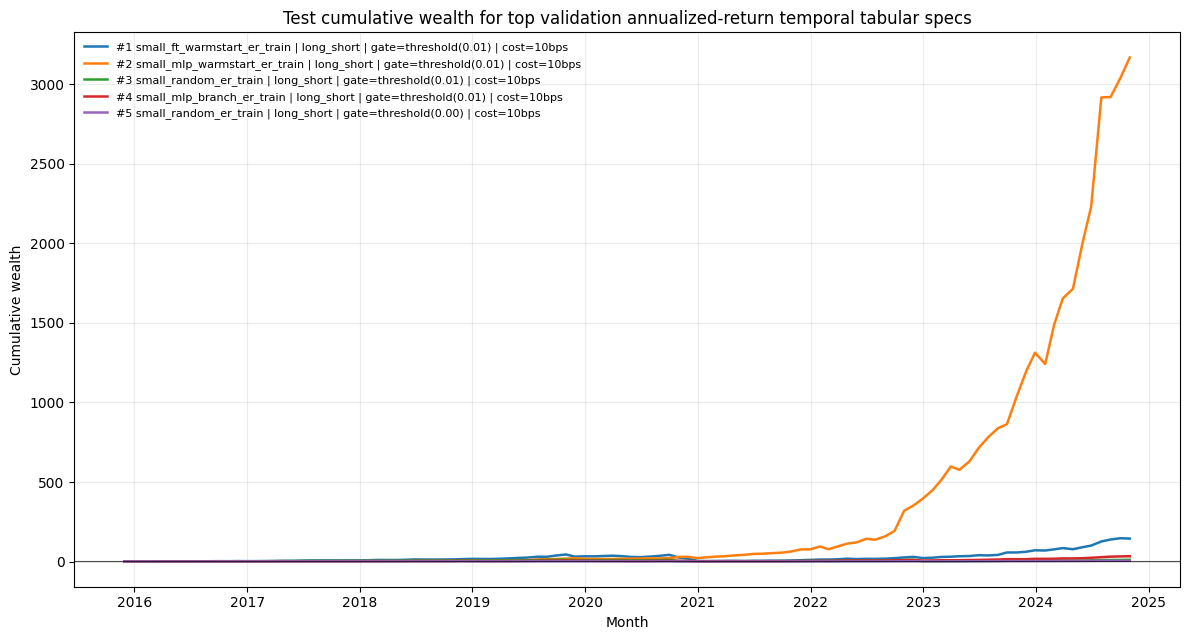

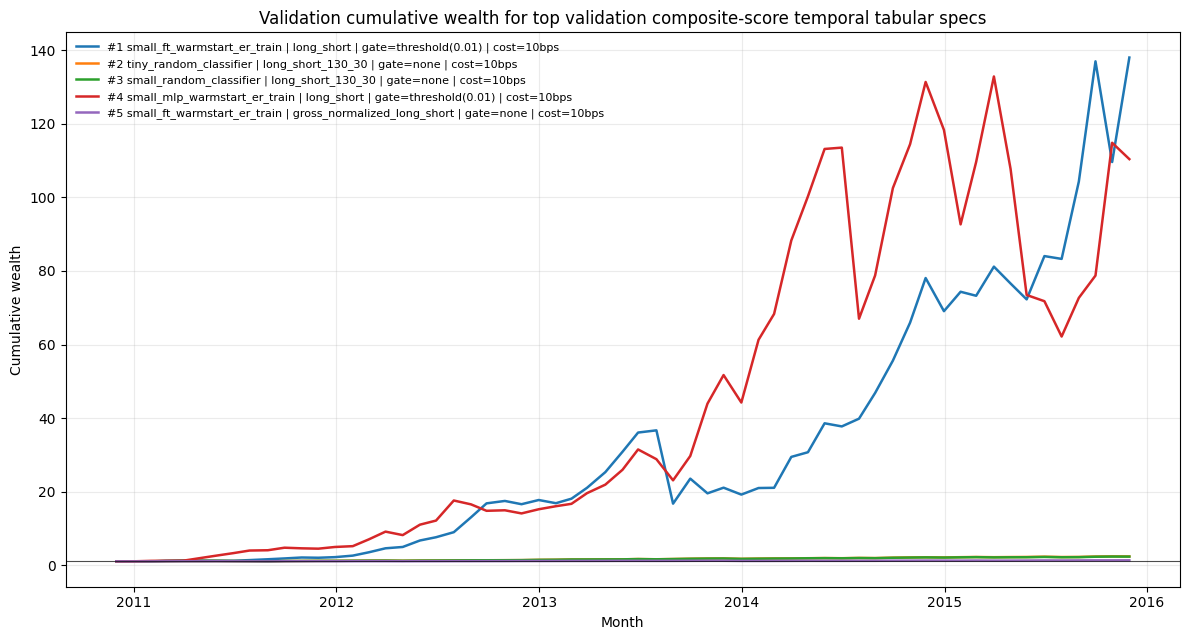

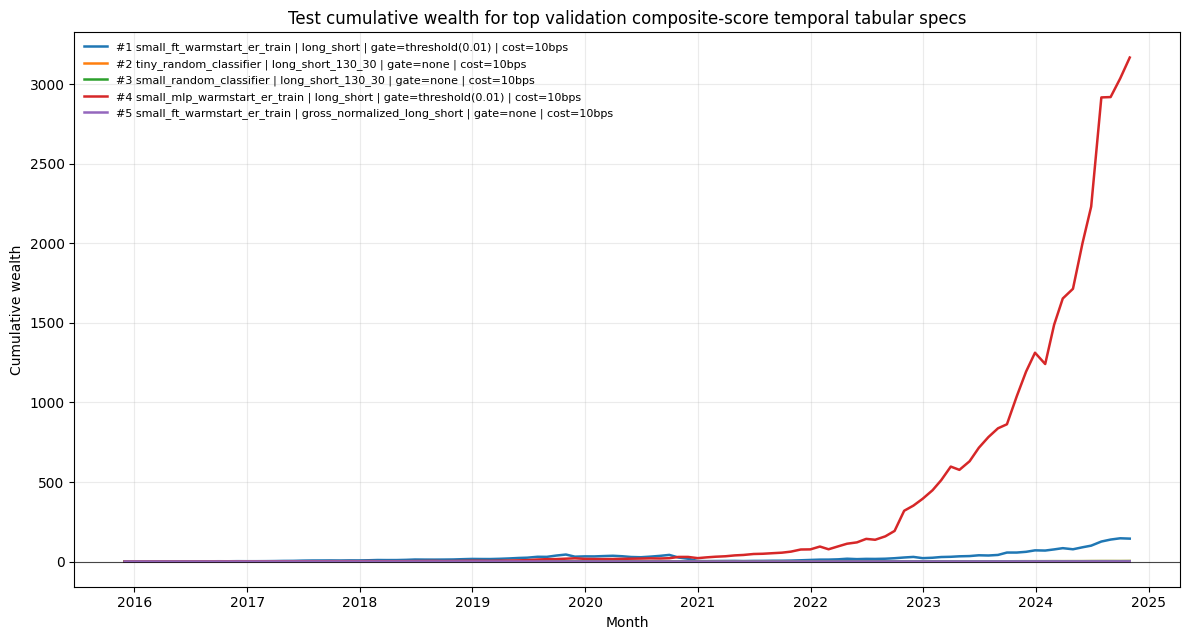

In [14]:
# Cell 12: Plot cumulative wealth for top validation specifications


def spec_filter(monthly: pd.DataFrame, spec: pd.Series, split: str) -> pd.Series:
    return monthly["split"].eq(split) & monthly["score_label"].eq(spec["score_label"]) & monthly["rule"].eq(spec["rule"]) & np.isclose(monthly["q"].astype(float), float(spec["q"])) & monthly["sign_gate"].eq(bool(spec["sign_gate"])) & monthly["threshold_gate"].eq(bool(spec["threshold_gate"])) & np.isclose(monthly["zero_threshold"].astype(float), float(spec["zero_threshold"])) & np.isclose(monthly["one_way_cost_bps"].astype(float), float(spec["one_way_cost_bps"]))


def plot_cumulative_wealth(monthly: pd.DataFrame, specs: pd.DataFrame, split: str, path: Path, title_suffix: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 6.5))
    plotted = 0
    for rank, (_, spec) in enumerate(specs.iterrows(), start=1):
        part = monthly.loc[spec_filter(monthly, spec, split)].sort_values("month")
        if part.empty:
            continue
        month_index = pd.to_datetime(part["month"].to_numpy())
        returns = pd.Series(part["net_return"].fillna(0.0).to_numpy(dtype="float64"), index=month_index)
        start_month = month_index[0] - pd.offsets.MonthBegin(1)
        wealth = pd.concat([pd.Series([1.0], index=[start_month]), (1.0 + returns).cumprod()])
        if spec["threshold_gate"]:
            gate_label = f"threshold({spec['zero_threshold']:.2f})"
        elif spec["sign_gate"]:
            gate_label = "sign"
        else:
            gate_label = "none"
        label = f"#{rank} {spec['score_label']} | {spec['rule']} | gate={gate_label} | cost={spec['one_way_cost_bps']:.0f}bps"
        ax.plot(wealth.index, wealth.values, linewidth=1.8, label=label)
        plotted += 1
    if plotted == 0:
        raise ValueError(f"No cumulative-wealth series found for split={split!r}.")
    ax.axhline(1.0, linewidth=0.8, color="black", alpha=0.7)
    ax.set_title(f"{split.title()} cumulative wealth for {title_suffix}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative wealth")
    ax.legend(fontsize=8, frameon=False, loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


top5_annual_return_specs = selection_table.head(5)[SPEC_COLUMNS].copy()
top5_composite_specs = selection_table.sort_values(["validation_composite_score", "validation_net_annualized_return", "validation_net_sharpe"], ascending=[False, False, False]).head(5)[SPEC_COLUMNS].copy()
plot_cumulative_wealth(portfolio_monthly, top5_annual_return_specs, "validation", FIGURE_DIR / "validation_top5_annual_return_temporal_tabular_strategy_cumulative_wealth.png", "top validation annualized-return temporal tabular specs")
plot_cumulative_wealth(portfolio_monthly, top5_annual_return_specs, "test", FIGURE_DIR / "test_top5_annual_return_temporal_tabular_strategy_cumulative_wealth.png", "top validation annualized-return temporal tabular specs")
plot_cumulative_wealth(portfolio_monthly, top5_composite_specs, "validation", FIGURE_DIR / "validation_top5_composite_temporal_tabular_strategy_cumulative_wealth.png", "top validation composite-score temporal tabular specs")
plot_cumulative_wealth(portfolio_monthly, top5_composite_specs, "test", FIGURE_DIR / "test_top5_composite_temporal_tabular_strategy_cumulative_wealth.png", "top validation composite-score temporal tabular specs")


## Z-score threshold-gated strategies

The following cells test a relative threshold gate for the temporal tabular scores. For each score and month t, scores are standardized cross-sectionally within that month. A numeric tau longs stocks with score z-score above tau and shorts stocks with score z-score below -tau. The `none` row is the no-threshold top/bottom 20% long-short control.


In [15]:
# Cell 13: Z-score-relative threshold strategy grid and backtests

ZSCORE_THRESHOLD_GRID = [None, 0.0, 0.25, 0.5, 1.0, 1.5]
ZSCORE_THRESHOLD_RULES = ["gross_normalized_long_short", "long_short", "long_short_130_30"]
ZSCORE_Q_FOR_NONE = 0.20


def format_zscore_tau(tau: float | None) -> str:
    if tau is None:
        return "none"
    return f"{float(tau):g}"


def monthly_score_zscore(scores: pd.Series) -> pd.Series:
    valid_scores = pd.to_numeric(scores, errors="coerce")
    mean = valid_scores.mean()
    std = valid_scores.std()
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=scores.index)
    return (valid_scores - mean) / std


def make_zscore_threshold_weights_for_month(
    part: pd.DataFrame,
    score_col: str,
    rule: str,
    tau: float | None,
    q_for_none: float = ZSCORE_Q_FOR_NONE,
    short_exposure: float = 1.0,
    long_exposure: float = 1.0,
) -> pd.Series:
    scores = pd.to_numeric(part[score_col], errors="coerce")
    valid = scores.notna()
    weights = pd.Series(0.0, index=part.index)
    if valid.sum() < 10:
        return weights

    if tau is None:
        ranks = scores[valid].rank(method="first", pct=True)
        long_idx = ranks[ranks >= 1 - q_for_none].index
        short_idx = ranks[ranks <= q_for_none].index
    else:
        score_z = monthly_score_zscore(scores.loc[valid])
        long_idx = score_z[score_z > tau].index
        short_idx = score_z[score_z < -tau].index

    if rule == "long_short":
        le, se = long_exposure, short_exposure
    elif rule == "gross_normalized_long_short":
        le, se = 0.5, 0.5
    elif rule == "long_short_130_30":
        le, se = 1.3, 0.3
    else:
        raise ValueError(f"Unknown z-score threshold rule: {rule}")

    if len(long_idx) > 0:
        weights.loc[long_idx] = le / len(long_idx)
    if len(short_idx) > 0:
        weights.loc[short_idx] = -se / len(short_idx)
    return weights


def build_zscore_threshold_portfolio_returns(
    data: pd.DataFrame,
    score_label: str,
    score_col: str,
    rule: str,
    tau: float | None,
    one_way_cost_bps: float = 0.0,
    target_col: str = "target_ret_1m",
    date_col: str = "MthCalDt",
    split_col: str = "split",
) -> pd.DataFrame:
    rows = []
    previous_weights_by_split: dict[str, pd.Series] = {}
    data = data.sort_values([split_col, date_col, "PERMNO"]).copy()

    for (split, month), part in data.groupby([split_col, date_col], sort=True, observed=True):
        weights = make_zscore_threshold_weights_for_month(part, score_col=score_col, rule=rule, tau=tau)
        returns = pd.to_numeric(part[target_col], errors="coerce").fillna(0.0)
        gross_return = float((weights * returns).sum())
        long_weight = weights.clip(lower=0).sum()
        short_weight = -weights.clip(upper=0).sum()
        gross_exposure = weights.abs().sum()
        net_exposure = weights.sum()
        long_return = float((weights.clip(lower=0) * returns).sum() / long_weight) if long_weight > 0 else np.nan
        short_leg_contribution = float((weights.clip(upper=0) * returns).sum()) if short_weight > 0 else np.nan
        short_leg_return = float(short_leg_contribution / short_weight) if short_weight > 0 else np.nan

        current_weights = pd.Series(weights.values, index=part["PERMNO"].values)
        previous_weights = previous_weights_by_split.get(split)
        if previous_weights is None:
            turnover = float(current_weights.abs().sum())
        else:
            aligned = pd.concat([previous_weights.rename("prev"), current_weights.rename("curr")], axis=1).fillna(0.0)
            turnover = float((aligned["curr"] - aligned["prev"]).abs().sum())

        cost = (one_way_cost_bps / 10_000.0) * turnover
        rows.append(
            {
                "split": split,
                "month": month,
                "score_label": score_label,
                "score_col": score_col,
                "rule": rule,
                "threshold_design": "monthly_score_zscore",
                "zscore_tau": format_zscore_tau(tau),
                "zscore_tau_value": np.nan if tau is None else float(tau),
                "q_for_none": ZSCORE_Q_FOR_NONE,
                "one_way_cost_bps": one_way_cost_bps,
                "gross_return": gross_return,
                "turnover": turnover,
                "trading_cost": cost,
                "net_return": gross_return - cost,
                "long_weight": float(long_weight),
                "short_weight": float(short_weight),
                "gross_exposure": float(gross_exposure),
                "net_exposure": float(net_exposure),
                "long_leg_return": long_return,
                "short_leg_return": short_leg_return,
                "short_leg_contribution": short_leg_contribution,
                "n_long": int((weights > 0).sum()),
                "n_short": int((weights < 0).sum()),
            }
        )
        previous_weights_by_split[split] = current_weights

    return pd.DataFrame(rows)


def summarize_zscore_threshold_portfolios(monthly: pd.DataFrame, return_col: str = "net_return") -> pd.DataFrame:
    rows = []
    group_cols = ["score_label", "rule", "threshold_design", "zscore_tau", "one_way_cost_bps", "split"]
    for keys, part in monthly.groupby(group_cols, observed=True):
        score_label, rule, threshold_design, zscore_tau, cost_bps, split = keys
        rets = part[return_col]
        run_label = score_to_run_label.get(score_label)
        rows.append(
            {
                "score_label": score_label,
                "run_label": run_label,
                "run_name": run_label_to_name.get(run_label),
                "score_type": "er_train" if score_label.endswith("_er_train") else "classifier",
                "rule": rule,
                "threshold_design": threshold_design,
                "zscore_tau": zscore_tau,
                "one_way_cost_bps": cost_bps,
                "split": split,
                "months": len(part),
                "annualized_return": annualized_return(rets),
                "annualized_volatility": annualized_volatility(rets),
                "sharpe": sharpe_ratio(rets),
                "max_drawdown": max_drawdown(rets),
                "mean_monthly_return": rets.mean(),
                "std_monthly_return": rets.std(),
                "average_turnover": part["turnover"].mean(),
                "average_gross_exposure": part["gross_exposure"].mean(),
                "average_net_exposure": part["net_exposure"].mean(),
                "average_long_weight": part["long_weight"].mean(),
                "average_short_weight": part["short_weight"].mean(),
                "average_n_long": part["n_long"].mean(),
                "average_n_short": part["n_short"].mean(),
                "average_long_leg_return": part["long_leg_return"].mean(),
                "average_short_leg_return": part["short_leg_return"].mean(),
                "average_short_leg_contribution": part["short_leg_contribution"].mean(),
            }
        )
    return pd.DataFrame(rows)


zscore_portfolio_frames = []
for score_label in candidate_score_labels:
    score_col = score_columns[score_label]
    for rule in ZSCORE_THRESHOLD_RULES:
        bt_none_cache = None
        for tau in ZSCORE_THRESHOLD_GRID:
            if tau is None:
                bt_none_cache = build_zscore_threshold_portfolio_returns(
                    work_small,
                    score_label=score_label,
                    score_col=score_col,
                    rule=rule,
                    tau=tau,
                    one_way_cost_bps=0.0,
                )
                bt_base = bt_none_cache
            else:
                bt_base = build_zscore_threshold_portfolio_returns(
                    work_small,
                    score_label=score_label,
                    score_col=score_col,
                    rule=rule,
                    tau=tau,
                    one_way_cost_bps=0.0,
                )
            for cost_bps in cost_grid_bps:
                bt = bt_base.copy()
                bt["one_way_cost_bps"] = cost_bps
                bt["trading_cost"] = (cost_bps / 10_000.0) * bt["turnover"]
                bt["net_return"] = bt["gross_return"] - bt["trading_cost"]
                zscore_portfolio_frames.append(bt)

zscore_threshold_monthly = pd.concat(zscore_portfolio_frames, ignore_index=True)
zscore_threshold_summary_net = summarize_zscore_threshold_portfolios(zscore_threshold_monthly, return_col="net_return")
zscore_threshold_summary_gross = summarize_zscore_threshold_portfolios(zscore_threshold_monthly, return_col="gross_return").rename(
    columns={"annualized_return": "gross_annualized_return", "annualized_volatility": "gross_annualized_volatility", "sharpe": "gross_sharpe", "max_drawdown": "gross_max_drawdown", "mean_monthly_return": "gross_mean_monthly_return", "std_monthly_return": "gross_std_monthly_return"}
)
ZSCORE_MERGE_COLUMNS = ["score_label", "run_label", "run_name", "score_type", "rule", "threshold_design", "zscore_tau", "one_way_cost_bps", "split"]
zscore_threshold_summary = zscore_threshold_summary_net.merge(
    zscore_threshold_summary_gross[ZSCORE_MERGE_COLUMNS + ["gross_annualized_return", "gross_annualized_volatility", "gross_sharpe", "gross_max_drawdown", "gross_mean_monthly_return", "gross_std_monthly_return"]],
    on=ZSCORE_MERGE_COLUMNS,
    how="left",
)

rank_ic_lookup = validation_rank_ic[["score_label", "mean_rank_ic", "rank_ic_tstat"]].rename(columns={"mean_rank_ic": "validation_rank_ic", "rank_ic_tstat": "validation_rank_ic_tstat"})
zscore_validation_portfolios = zscore_threshold_summary.loc[zscore_threshold_summary["split"].eq("validation")].merge(rank_ic_lookup, on="score_label", how="left", validate="many_to_one").copy()
zscore_validation_portfolios["validation_net_sharpe"] = zscore_validation_portfolios["sharpe"]
zscore_validation_portfolios["validation_net_annualized_return"] = zscore_validation_portfolios["annualized_return"]
zscore_validation_portfolios["validation_net_annualized_volatility"] = zscore_validation_portfolios["annualized_volatility"]
zscore_validation_portfolios["eligible_for_selection"] = zscore_validation_portfolios["validation_rank_ic"].notna() & zscore_validation_portfolios["validation_net_sharpe"].notna() & zscore_validation_portfolios["validation_net_annualized_return"].notna() & zscore_validation_portfolios["validation_net_annualized_volatility"].notna() & zscore_validation_portfolios["average_turnover"].notna() & zscore_validation_portfolios["average_turnover"].gt(0) & zscore_validation_portfolios["average_gross_exposure"].gt(0) & zscore_validation_portfolios["validation_net_annualized_volatility"].gt(0)
zscore_validation_portfolios["validation_composite_score"] = zscore_validation_portfolios["validation_rank_ic"] + zscore_validation_portfolios["validation_net_sharpe"] + zscore_validation_portfolios["validation_net_annualized_return"] - zscore_validation_portfolios["average_turnover"] - zscore_validation_portfolios["validation_net_annualized_volatility"]
zscore_validation_portfolios.loc[~zscore_validation_portfolios["eligible_for_selection"], "validation_composite_score"] = -np.inf
zscore_validation_portfolios = zscore_validation_portfolios.sort_values(["one_way_cost_bps", "eligible_for_selection", "validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"], ascending=[True, False, False, False, False]).reset_index(drop=True)

ZSCORE_VALIDATION_RANKING_COLUMNS = ["score_label", "run_name", "score_type", "rule", "zscore_tau", "one_way_cost_bps", "validation_composite_score", "validation_rank_ic", "validation_rank_ic_tstat", "validation_net_sharpe", "validation_net_annualized_return", "validation_net_annualized_volatility", "average_turnover", "eligible_for_selection", "average_n_long", "average_n_short", "average_gross_exposure", "average_long_leg_return", "average_short_leg_return", "average_short_leg_contribution", "max_drawdown"]

zscore_threshold_monthly.to_csv(BACKTEST_DIR / "temporal_tabular_zscore_threshold_monthly_returns.csv", index=False)
zscore_threshold_summary.to_csv(BACKTEST_DIR / "temporal_tabular_zscore_threshold_performance_summary.csv", index=False)
zscore_validation_portfolios.to_csv(BACKTEST_DIR / "validation_temporal_tabular_zscore_threshold_strategy_ranking.csv", index=False)

zscore_validation_rankings_by_cost = {}
for cost in cost_grid_bps:
    ranking = zscore_validation_portfolios.loc[zscore_validation_portfolios["one_way_cost_bps"].eq(cost)].reset_index(drop=True)
    zscore_validation_rankings_by_cost[cost] = ranking
    ranking.to_csv(BACKTEST_DIR / f"validation_temporal_tabular_zscore_threshold_strategy_ranking_{int(cost)}bps.csv", index=False)
    print(f"Z-score threshold validation ranking by net annualized return at {cost:.0f} bps")
    display(ranking[ZSCORE_VALIDATION_RANKING_COLUMNS].head(30))

zscore_selection_table = zscore_validation_portfolios.loc[zscore_validation_portfolios["one_way_cost_bps"].eq(SELECTION_COST_BPS) & zscore_validation_portfolios["eligible_for_selection"]].sort_values(["validation_net_annualized_return", "validation_net_sharpe", "validation_composite_score"], ascending=[False, False, False]).reset_index(drop=True)
if zscore_selection_table.empty:
    raise ValueError("No eligible z-score threshold validation strategies found.")
zscore_selection_table.to_csv(BACKTEST_DIR / "validation_temporal_tabular_zscore_threshold_selection_table_10bps.csv", index=False)
display(zscore_selection_table[ZSCORE_VALIDATION_RANKING_COLUMNS].head(30))


Z-score threshold validation ranking by net annualized return at 0 bps


,score_label,run_name,score_type,rule,zscore_tau,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,1.5,0.0,-0.176900,0.053489,3.307935,1.385353,0.240317,0.173470,1.682589,True,229.000000,363.166667,2.000000,0.012548,0.006807,0.006807,-0.188898
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,1.5,0.0,-0.885148,0.041050,2.531480,1.000596,0.231610,0.231472,1.926933,True,421.583333,273.800000,2.000000,0.008716,0.011108,0.011108,-0.272727
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,1.5,0.0,-0.345522,0.058306,5.172353,1.148100,0.222750,0.194016,1.580662,True,76.983333,378.166667,2.000000,0.011127,0.007303,0.007303,-0.224658
3,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short_130_30,1.5,0.0,-0.456257,0.053489,3.307935,1.009266,0.216987,0.214995,1.521005,True,229.000000,363.166667,1.600000,0.012548,0.006807,0.002042,-0.229196
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short_130_30,1.5,0.0,0.364488,0.058306,5.172353,1.709653,0.210390,0.123060,1.490801,True,76.983333,378.166667,1.600000,0.011127,0.007303,0.002191,-0.097172
5,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,1.5,0.0,-0.291319,0.050567,3.635593,1.158965,0.210202,0.181370,1.529682,True,182.083333,323.533333,2.000000,0.009601,0.007816,0.007816,-0.185491
6,small_mlp_warmstart_classifier,temporal_tabular_small_mlp_warmstart,classifier,long_short,1.5,0.0,-0.315573,0.077250,6.669270,1.261611,0.202148,0.160230,1.696352,True,177.966667,606.400000,2.000000,0.010200,0.006323,0.006323,-0.192083
7,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,1.5,0.0,0.032515,0.093132,6.503703,1.293388,0.200080,0.154694,1.399390,True,12.933333,616.450000,1.231667,0.016039,0.004254,0.001276,-0.106973
8,tiny_random_classifier,temporal_tabular_tiny_random,classifier,long_short_130_30,1,0.0,0.430048,0.097549,7.534537,1.761609,0.199743,0.113387,1.515467,True,265.666667,1087.000000,1.600000,0.011424,0.003217,0.000965,-0.110157
9,tiny_random_classifier,temporal_tabular_tiny_random,classifier,long_short_130_30,none,0.0,1.656183,0.097549,7.534537,1.874910,0.192397,0.102617,0.406056,True,1351.516667,1350.516667,1.600000,0.011228,0.002014,0.000604,-0.105323


Z-score threshold validation ranking by net annualized return at 10 bps


,score_label,run_name,score_type,rule,zscore_tau,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,1.5,10.0,-0.341884,0.053489,3.307935,1.244761,0.215910,0.173455,1.682589,True,229.000000,363.166667,2.000000,0.012548,0.006807,0.006807,-0.195064
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,1.5,10.0,-1.032142,0.041050,2.531480,0.881220,0.203873,0.231353,1.926933,True,421.583333,273.800000,2.000000,0.008716,0.011108,0.011108,-0.274720
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,1.5,10.0,-0.486584,0.058306,5.172353,1.029954,0.200051,0.194233,1.580662,True,76.983333,378.166667,2.000000,0.011127,0.007303,0.007303,-0.235372
3,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short_130_30,1.5,10.0,-0.576986,0.053489,3.307935,0.909878,0.195342,0.214691,1.521005,True,229.000000,363.166667,1.600000,0.012548,0.006807,0.002042,-0.234369
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short_130_30,1.5,10.0,0.166608,0.058306,5.172353,1.533300,0.189190,0.123387,1.490801,True,76.983333,378.166667,1.600000,0.011127,0.007303,0.002191,-0.101575
5,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,1.5,10.0,-0.433138,0.050567,3.635593,1.038917,0.188475,0.181415,1.529682,True,182.083333,323.533333,2.000000,0.009601,0.007816,0.007816,-0.195512
6,tiny_random_classifier,temporal_tabular_tiny_random,classifier,long_short_130_30,none,10.0,1.593435,0.097549,7.534537,1.817951,0.186674,0.102684,0.406056,True,1351.516667,1350.516667,1.600000,0.011228,0.002014,0.000604,-0.106460
7,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,none,10.0,1.577873,0.093132,6.503703,1.799516,0.180772,0.100456,0.395091,True,1351.516667,1350.516667,1.600000,0.010918,0.001853,0.000556,-0.103551
8,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,1.5,10.0,-0.109294,0.093132,6.503703,1.170658,0.180445,0.154140,1.399390,True,12.933333,616.450000,1.231667,0.016039,0.004254,0.001276,-0.117673
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short_130_30,1,10.0,0.578333,0.079008,7.352566,1.356311,0.179483,0.132332,0.904137,True,886.750000,999.816667,1.600000,0.011364,0.002324,0.000697,-0.174802


Z-score threshold validation ranking by net annualized return at 25 bps


,score_label,run_name,score_type,rule,zscore_tau,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,1.5,25.0,-0.584095,0.053489,3.307935,1.038352,0.180118,0.173465,1.682589,True,229.000000,363.166667,2.000000,0.012548,0.006807,0.006807,-0.204248
1,tiny_random_classifier,temporal_tabular_tiny_random,classifier,long_short_130_30,none,25.0,1.499825,0.097549,7.534537,1.732987,0.178135,0.102791,0.406056,True,1351.516667,1350.516667,1.600000,0.011228,0.002014,0.000604,-0.108162
2,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,none,25.0,1.485095,0.093132,6.503703,1.715129,0.172499,0.100575,0.395091,True,1351.516667,1350.516667,1.600000,0.010918,0.001853,0.000556,-0.105168
3,small_random_er_train,temporal_tabular_small_random,er_train,long_short,1.5,25.0,-0.693359,0.058306,5.172353,0.856851,0.166723,0.194576,1.580662,True,76.983333,378.166667,2.000000,0.011127,0.007303,0.007303,-0.251201
4,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short_130_30,1.5,25.0,-0.754989,0.053489,3.307935,0.763251,0.163531,0.214256,1.521005,True,229.000000,363.166667,1.600000,0.012548,0.006807,0.002042,-0.242076
5,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,1.5,25.0,-1.247313,0.041050,2.531480,0.706441,0.163332,0.231203,1.926933,True,421.583333,273.800000,2.000000,0.008716,0.011108,0.011108,-0.277711
6,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,1,25.0,1.052967,0.093132,6.503703,1.656775,0.160812,0.097063,0.760689,True,654.916667,925.683333,1.600000,0.010669,0.003073,0.000922,-0.097287
7,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short_130_30,1,25.0,0.417562,0.079008,7.352566,1.214331,0.160679,0.132319,0.904137,True,886.750000,999.816667,1.600000,0.011364,0.002324,0.000697,-0.180218
8,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,0.5,25.0,1.337068,0.093132,6.503703,1.525044,0.159229,0.104409,0.335928,True,2162.383333,1364.800000,1.600000,0.010087,0.001869,0.000561,-0.124726
9,small_random_er_train,temporal_tabular_small_random,er_train,long_short_130_30,1.5,25.0,-0.122982,0.058306,5.172353,1.275392,0.158023,0.123902,1.490801,True,76.983333,378.166667,1.600000,0.011127,0.007303,0.002191,-0.108152


,score_label,run_name,score_type,rule,zscore_tau,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,1.5,10.0,-0.341884,0.053489,3.307935,1.244761,0.215910,0.173455,1.682589,True,229.000000,363.166667,2.000000,0.012548,0.006807,0.006807,-0.195064
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,1.5,10.0,-1.032142,0.041050,2.531480,0.881220,0.203873,0.231353,1.926933,True,421.583333,273.800000,2.000000,0.008716,0.011108,0.011108,-0.274720
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,1.5,10.0,-0.486584,0.058306,5.172353,1.029954,0.200051,0.194233,1.580662,True,76.983333,378.166667,2.000000,0.011127,0.007303,0.007303,-0.235372
3,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short_130_30,1.5,10.0,-0.576986,0.053489,3.307935,0.909878,0.195342,0.214691,1.521005,True,229.000000,363.166667,1.600000,0.012548,0.006807,0.002042,-0.234369
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short_130_30,1.5,10.0,0.166608,0.058306,5.172353,1.533300,0.189190,0.123387,1.490801,True,76.983333,378.166667,1.600000,0.011127,0.007303,0.002191,-0.101575
5,small_mlp_branch_er_train,temporal_tabular_small_mlp_branch,er_train,long_short,1.5,10.0,-0.433138,0.050567,3.635593,1.038917,0.188475,0.181415,1.529682,True,182.083333,323.533333,2.000000,0.009601,0.007816,0.007816,-0.195512
6,tiny_random_classifier,temporal_tabular_tiny_random,classifier,long_short_130_30,none,10.0,1.593435,0.097549,7.534537,1.817951,0.186674,0.102684,0.406056,True,1351.516667,1350.516667,1.600000,0.011228,0.002014,0.000604,-0.106460
7,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,none,10.0,1.577873,0.093132,6.503703,1.799516,0.180772,0.100456,0.395091,True,1351.516667,1350.516667,1.600000,0.010918,0.001853,0.000556,-0.103551
8,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,1.5,10.0,-0.109294,0.093132,6.503703,1.170658,0.180445,0.154140,1.399390,True,12.933333,616.450000,1.231667,0.016039,0.004254,0.001276,-0.117673
9,tiny_random_er_train,temporal_tabular_tiny_random,er_train,long_short_130_30,1,10.0,0.578333,0.079008,7.352566,1.356311,0.179483,0.132332,0.904137,True,886.750000,999.816667,1.600000,0.011364,0.002324,0.000697,-0.174802


Top 5 z-score threshold specifications by validation net annualized return at 10 bps


,score_label,run_name,score_type,rule,zscore_tau,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
0,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short,1.5,10.0,-0.341884,0.053489,3.307935,1.244761,0.215910,0.173455,1.682589,True,229.000000,363.166667,2.0,0.012548,0.006807,0.006807,-0.195064
1,small_mlp_warmstart_er_train,temporal_tabular_small_mlp_warmstart,er_train,long_short,1.5,10.0,-1.032142,0.041050,2.531480,0.881220,0.203873,0.231353,1.926933,True,421.583333,273.800000,2.0,0.008716,0.011108,0.011108,-0.274720
2,small_random_er_train,temporal_tabular_small_random,er_train,long_short,1.5,10.0,-0.486584,0.058306,5.172353,1.029954,0.200051,0.194233,1.580662,True,76.983333,378.166667,2.0,0.011127,0.007303,0.007303,-0.235372
3,default_seed362559_er_train,temporal_tabular_transformer_seed362559,er_train,long_short_130_30,1.5,10.0,-0.576986,0.053489,3.307935,0.909878,0.195342,0.214691,1.521005,True,229.000000,363.166667,1.6,0.012548,0.006807,0.002042,-0.234369
4,small_random_er_train,temporal_tabular_small_random,er_train,long_short_130_30,1.5,10.0,0.166608,0.058306,5.172353,1.533300,0.189190,0.123387,1.490801,True,76.983333,378.166667,1.6,0.011127,0.007303,0.002191,-0.101575


Top 5 z-score threshold specifications by validation composite score at 10 bps


,score_label,run_name,score_type,rule,zscore_tau,one_way_cost_bps,validation_composite_score,validation_rank_ic,validation_rank_ic_tstat,validation_net_sharpe,validation_net_annualized_return,validation_net_annualized_volatility,average_turnover,eligible_for_selection,average_n_long,average_n_short,average_gross_exposure,average_long_leg_return,average_short_leg_return,average_short_leg_contribution,max_drawdown
6,tiny_random_classifier,temporal_tabular_tiny_random,classifier,long_short_130_30,none,10.0,1.593435,0.097549,7.534537,1.817951,0.186674,0.102684,0.406056,True,1351.516667,1350.516667,1.6,0.011228,0.002014,0.000604,-0.106460
7,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,none,10.0,1.577873,0.093132,6.503703,1.799516,0.180772,0.100456,0.395091,True,1351.516667,1350.516667,1.6,0.010918,0.001853,0.000556,-0.103551
16,small_random_classifier,temporal_tabular_small_random,classifier,long_short_130_30,0.5,10.0,1.411894,0.093132,6.503703,1.592837,0.166184,0.104332,0.335928,True,2162.383333,1364.800000,1.6,0.010087,0.001869,0.000561,-0.122739
198,small_random_er_train,temporal_tabular_small_random,er_train,gross_normalized_long_short,0,10.0,1.309111,0.058306,5.172353,1.401346,0.034923,0.024921,0.160543,True,3840.783333,2913.616667,1.0,0.007959,-0.001858,-0.000929,-0.029731
193,small_random_er_train,temporal_tabular_small_random,er_train,gross_normalized_long_short,0.25,10.0,1.279962,0.058306,5.172353,1.393259,0.039511,0.028359,0.182754,True,3329.983333,2507.416667,1.0,0.008927,-0.002026,-0.001013,-0.034888


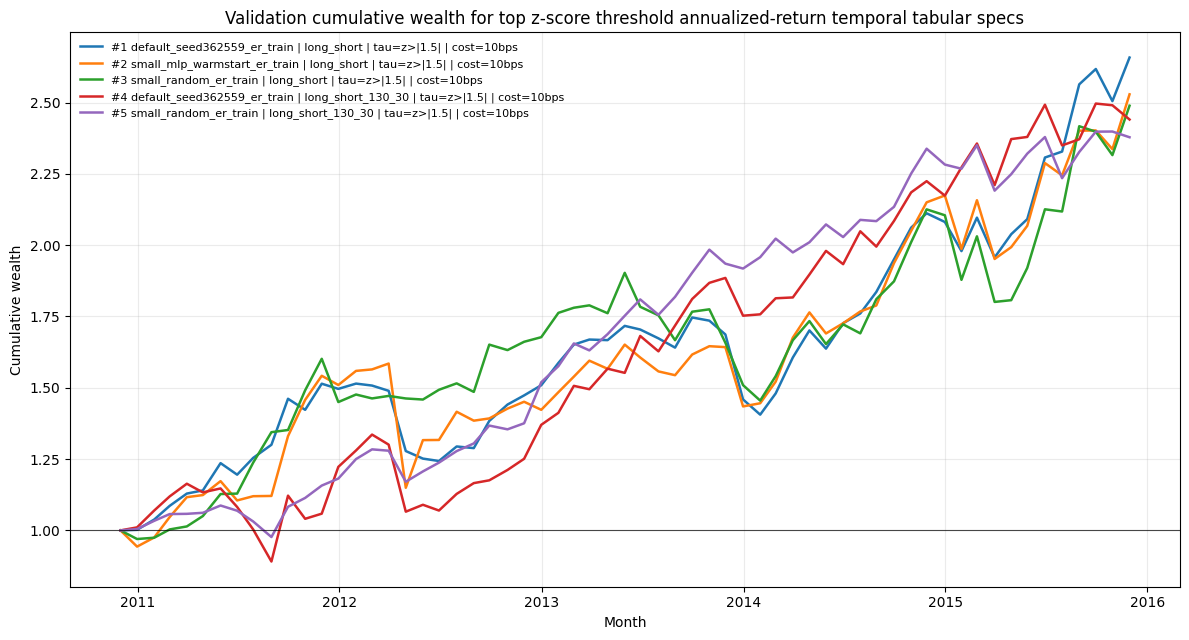

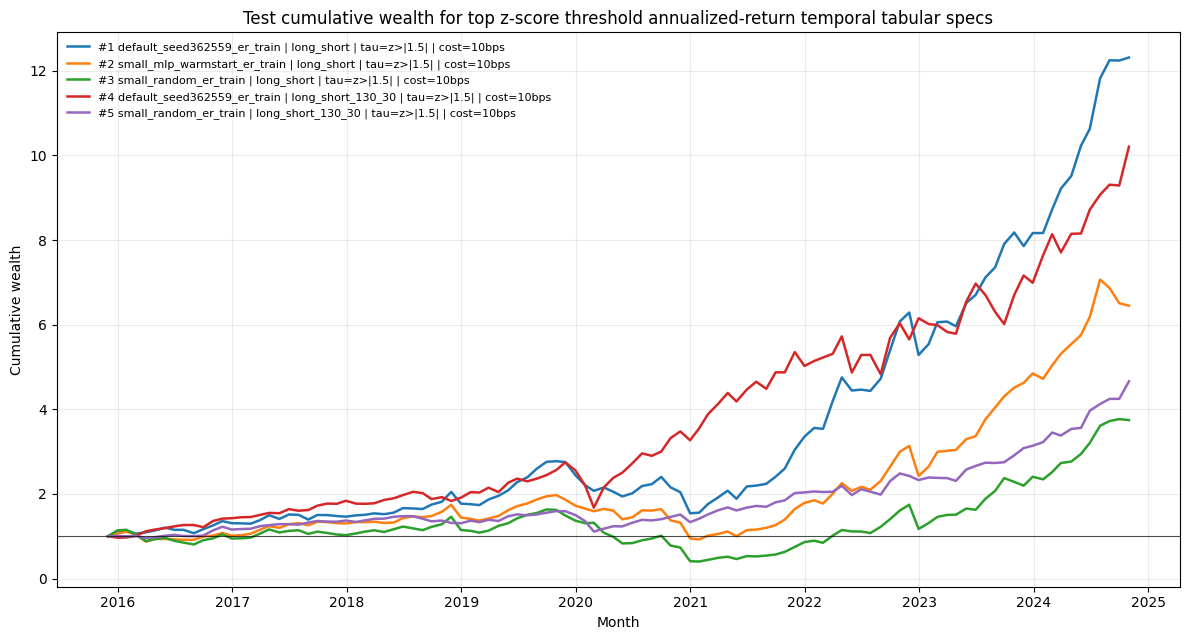

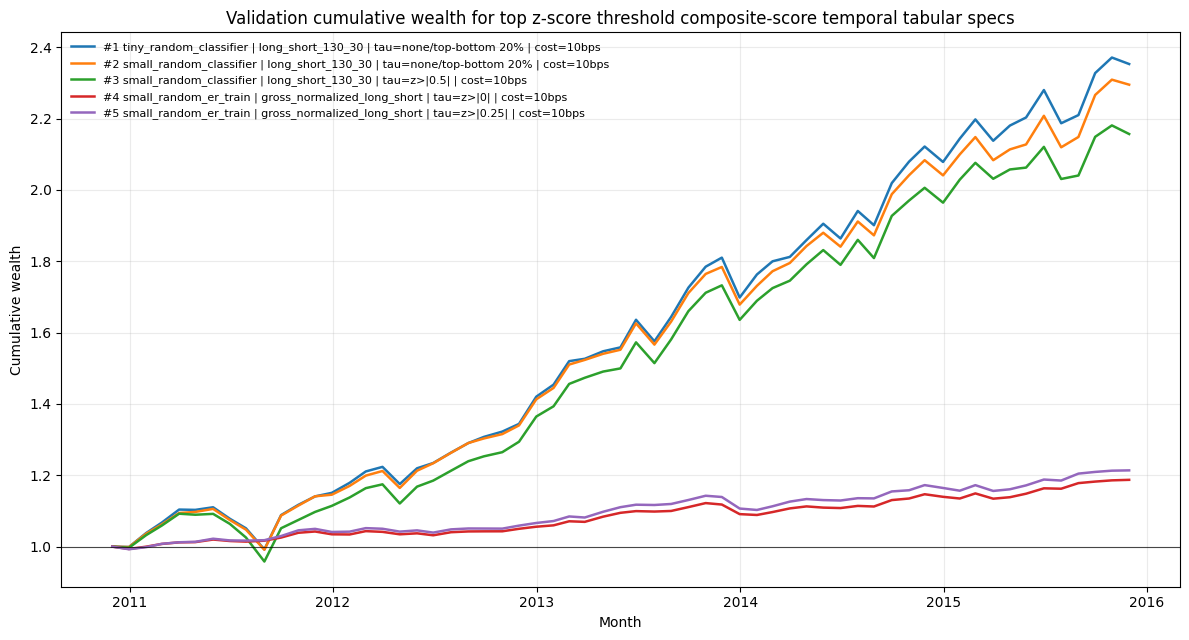

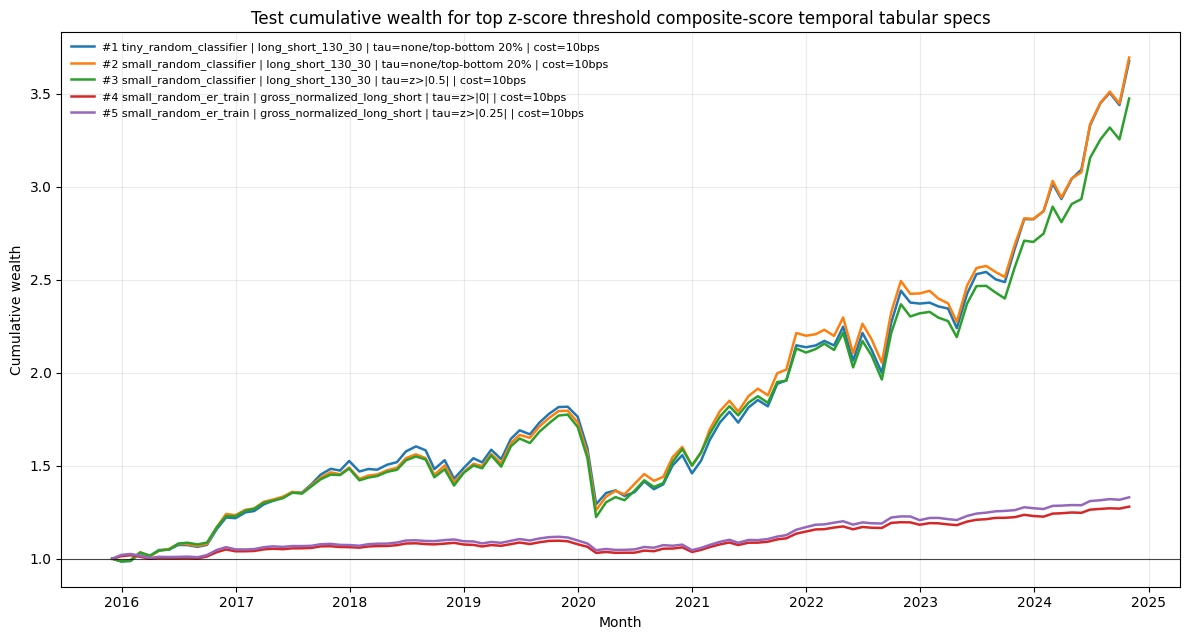

In [16]:
# Cell 14: Plot the best z-score threshold strategies

ZSCORE_SPEC_COLUMNS = ["score_label", "rule", "threshold_design", "zscore_tau", "one_way_cost_bps"]


def zscore_spec_filter(monthly: pd.DataFrame, spec: pd.Series, split: str) -> pd.Series:
    return monthly["split"].eq(split) & monthly["score_label"].eq(spec["score_label"]) & monthly["rule"].eq(spec["rule"]) & monthly["threshold_design"].eq(spec["threshold_design"]) & monthly["zscore_tau"].eq(spec["zscore_tau"]) & np.isclose(monthly["one_way_cost_bps"].astype(float), float(spec["one_way_cost_bps"]))


def plot_zscore_threshold_cumulative_wealth(monthly: pd.DataFrame, specs: pd.DataFrame, split: str, path: Path, title_suffix: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 6.5))
    plotted = 0
    for rank, (_, spec) in enumerate(specs.iterrows(), start=1):
        part = monthly.loc[zscore_spec_filter(monthly, spec, split)].sort_values("month")
        if part.empty:
            continue
        month_index = pd.to_datetime(part["month"].to_numpy())
        returns = pd.Series(part["net_return"].fillna(0.0).to_numpy(dtype="float64"), index=month_index)
        start_month = month_index[0] - pd.offsets.MonthBegin(1)
        wealth = pd.concat([pd.Series([1.0], index=[start_month]), (1.0 + returns).cumprod()])
        tau_label = "none/top-bottom 20%" if spec["zscore_tau"] == "none" else f"z>|{spec['zscore_tau']}|"
        label = f"#{rank} {spec['score_label']} | {spec['rule']} | tau={tau_label} | cost={spec['one_way_cost_bps']:.0f}bps"
        ax.plot(wealth.index, wealth.values, linewidth=1.8, label=label)
        plotted += 1
    if plotted == 0:
        raise ValueError(f"No z-score threshold cumulative-wealth series found for split={split!r}.")
    ax.axhline(1.0, linewidth=0.8, color="black", alpha=0.7)
    ax.set_title(f"{split.title()} cumulative wealth for {title_suffix}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative wealth")
    ax.legend(fontsize=8, frameon=False, loc="best")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


top5_zscore_annual_return_specs = zscore_selection_table.head(5)[ZSCORE_SPEC_COLUMNS].copy()
top5_zscore_composite_specs = zscore_selection_table.sort_values(["validation_composite_score", "validation_net_annualized_return", "validation_net_sharpe"], ascending=[False, False, False]).head(5)[ZSCORE_SPEC_COLUMNS].copy()
print(f"Top 5 z-score threshold specifications by validation net annualized return at {SELECTION_COST_BPS:.0f} bps")
display(zscore_selection_table.head(5)[ZSCORE_VALIDATION_RANKING_COLUMNS])
print(f"Top 5 z-score threshold specifications by validation composite score at {SELECTION_COST_BPS:.0f} bps")
display(zscore_selection_table.sort_values(["validation_composite_score", "validation_net_annualized_return", "validation_net_sharpe"], ascending=[False, False, False]).head(5)[ZSCORE_VALIDATION_RANKING_COLUMNS])

plot_zscore_threshold_cumulative_wealth(zscore_threshold_monthly, top5_zscore_annual_return_specs, "validation", FIGURE_DIR / "validation_top5_annual_return_temporal_tabular_zscore_threshold_cumulative_wealth.png", "top z-score threshold annualized-return temporal tabular specs")
plot_zscore_threshold_cumulative_wealth(zscore_threshold_monthly, top5_zscore_annual_return_specs, "test", FIGURE_DIR / "test_top5_annual_return_temporal_tabular_zscore_threshold_cumulative_wealth.png", "top z-score threshold annualized-return temporal tabular specs")
plot_zscore_threshold_cumulative_wealth(zscore_threshold_monthly, top5_zscore_composite_specs, "validation", FIGURE_DIR / "validation_top5_composite_temporal_tabular_zscore_threshold_cumulative_wealth.png", "top z-score threshold composite-score temporal tabular specs")
plot_zscore_threshold_cumulative_wealth(zscore_threshold_monthly, top5_zscore_composite_specs, "test", FIGURE_DIR / "test_top5_composite_temporal_tabular_zscore_threshold_cumulative_wealth.png", "top z-score threshold composite-score temporal tabular specs")


In [17]:
# Cell 15: Output manifest

output_manifest = pd.DataFrame(
    [
        {"artifact": "merged_predictions", "path": PREDICTION_DIR / "temporal_tabular_backtest_predictions.parquet"},
        {"artifact": "loaded_runs", "path": TABLE_DIR / "temporal_tabular_backtest_loaded_runs.csv"},
        {"artifact": "prediction_coverage", "path": TABLE_DIR / "temporal_tabular_backtest_prediction_coverage.csv"},
        {"artifact": "monthly_rank_ic", "path": BACKTEST_DIR / "temporal_tabular_score_monthly_rank_ic.csv"},
        {"artifact": "rank_ic_summary", "path": BACKTEST_DIR / "temporal_tabular_score_rank_ic_summary.csv"},
        {"artifact": "monthly_returns", "path": BACKTEST_DIR / "temporal_tabular_score_strategy_monthly_returns.csv"},
        {"artifact": "performance_summary", "path": BACKTEST_DIR / "temporal_tabular_score_strategy_performance_summary.csv"},
        {"artifact": "zscore_threshold_monthly_returns", "path": BACKTEST_DIR / "temporal_tabular_zscore_threshold_monthly_returns.csv"},
        {"artifact": "zscore_threshold_performance_summary", "path": BACKTEST_DIR / "temporal_tabular_zscore_threshold_performance_summary.csv"},
        {"artifact": "zscore_threshold_validation_ranking", "path": BACKTEST_DIR / "validation_temporal_tabular_zscore_threshold_strategy_ranking.csv"},
        {"artifact": "zscore_threshold_selection_table_10bps", "path": BACKTEST_DIR / "validation_temporal_tabular_zscore_threshold_selection_table_10bps.csv"},
        {"artifact": "validation_ranking", "path": BACKTEST_DIR / "validation_temporal_tabular_score_strategy_ranking.csv"},
        {"artifact": "selection_table_10bps", "path": BACKTEST_DIR / "validation_temporal_tabular_selection_table_10bps.csv"},
        {"artifact": "chosen_validation_spec", "path": BACKTEST_DIR / "chosen_validation_temporal_tabular_specification.csv"},
        {"artifact": "chosen_test_performance", "path": BACKTEST_DIR / "test_performance_of_chosen_validation_temporal_tabular_spec.csv"},
        {"artifact": "figures", "path": FIGURE_DIR},
    ]
)
output_manifest["path"] = output_manifest["path"].map(lambda p: str(Path(p).relative_to(REPO_ROOT)))
output_manifest.to_csv(BACKTEST_DIR / "temporal_tabular_backtest_output_manifest.csv", index=False)
display(output_manifest)
print("Temporal tabular backtest complete.")


,artifact,path
0,merged_predictions,outputs/predictions/temporal_tabular_backtest_...
1,loaded_runs,outputs/tables/temporal_tabular_backtest_loade...
2,prediction_coverage,outputs/tables/temporal_tabular_backtest_predi...
3,monthly_rank_ic,outputs/backtests/temporal_tabular_score_strat...
4,rank_ic_summary,outputs/backtests/temporal_tabular_score_strat...
5,monthly_returns,outputs/backtests/temporal_tabular_score_strat...
6,performance_summary,outputs/backtests/temporal_tabular_score_strat...
7,zscore_threshold_monthly_returns,outputs/backtests/temporal_tabular_score_strat...
8,zscore_threshold_performance_summary,outputs/backtests/temporal_tabular_score_strat...
9,zscore_threshold_validation_ranking,outputs/backtests/temporal_tabular_score_strat...


Temporal tabular backtest complete.


In [18]:
# Cell 16: Timing-clean DD risk overlays with scaled transaction costs

DD_PHASE_SPLIT = "validation"
DD_PHASE_COST_BPS = SELECTION_COST_BPS
DD_PHASE_MIN_RANK_IC_TSTAT = 1.96
DD_PHASE_MAX_TURNOVER = 1.75
DD_PHASE_REENTRY_2M_THRESHOLD = 0.02
DD_PHASE_PLOT_N = 6


def gross_normalized_return_series(part: pd.DataFrame, return_col: str) -> pd.Series:
    gross_exposure = part["gross_exposure"].replace(0, np.nan)
    return part[return_col] / gross_exposure


def summarize_gross_normalized_strategy_returns(monthly: pd.DataFrame, spec_cols: list[str], return_col: str) -> pd.DataFrame:
    rows = []
    for keys, part in monthly.groupby(spec_cols + ["split"], observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        split = keys[-1]
        spec_values = keys[:-1]
        gn_rets = gross_normalized_return_series(part, return_col=return_col)
        row = {col: value for col, value in zip(spec_cols, spec_values)}
        row.update(
            {
                "split": split,
                "gross_normalized_annualized_return": annualized_return(gn_rets),
                "gross_normalized_annualized_volatility": annualized_volatility(gn_rets),
                "gross_normalized_sharpe": sharpe_ratio(gn_rets),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


ABS_SPEC_COLUMNS = ["score_label", "rule", "q", "sign_gate", "threshold_gate", "zero_threshold", "one_way_cost_bps"]
ZSCORE_SPEC_COLUMNS = ["score_label", "rule", "threshold_design", "zscore_tau", "one_way_cost_bps"]

abs_summary_all = portfolio_summary.copy()
abs_summary_all["threshold_design"] = np.select(
    [abs_summary_all["threshold_gate"].astype(bool), abs_summary_all["sign_gate"].astype(bool)],
    ["absolute_score_threshold", "score_sign"],
    default="none",
)
abs_summary_all["threshold_label"] = np.where(
    abs_summary_all["threshold_gate"].astype(bool),
    abs_summary_all["zero_threshold"].map(lambda x: f"abs>{float(x):g}"),
    np.where(abs_summary_all["sign_gate"].astype(bool), "sign", "none"),
)
abs_summary_all["q_for_none"] = abs_summary_all["q"]
abs_summary_all["strategy_family"] = "absolute_or_none"
abs_summary_all["strategy_id"] = (
    abs_summary_all["score_label"]
    + " | "
    + abs_summary_all["rule"]
    + " | "
    + abs_summary_all["threshold_label"]
    + " | cost="
    + abs_summary_all["one_way_cost_bps"].map(lambda x: f"{float(x):g}bps")
)

zscore_summary_all = zscore_threshold_summary.copy()
zscore_summary_all["threshold_label"] = np.where(
    zscore_summary_all["zscore_tau"].eq("none"),
    "none/top-bottom 20%",
    "z>|" + zscore_summary_all["zscore_tau"].astype(str) + "|",
)
zscore_summary_all["q"] = ZSCORE_Q_FOR_NONE
zscore_summary_all["sign_gate"] = False
zscore_summary_all["threshold_gate"] = zscore_summary_all["zscore_tau"].ne("none")
zscore_summary_all["zero_threshold"] = np.nan
zscore_summary_all["q_for_none"] = ZSCORE_Q_FOR_NONE
zscore_summary_all["strategy_family"] = "zscore_relative_or_none"
zscore_summary_all["strategy_id"] = (
    zscore_summary_all["score_label"]
    + " | "
    + zscore_summary_all["rule"]
    + " | "
    + zscore_summary_all["threshold_label"]
    + " | cost="
    + zscore_summary_all["one_way_cost_bps"].map(lambda x: f"{float(x):g}bps")
)

COMMON_SUMMARY_COLUMNS = [
    "strategy_family",
    "strategy_id",
    "score_label",
    "run_name",
    "score_type",
    "rule",
    "threshold_design",
    "threshold_label",
    "q",
    "q_for_none",
    "sign_gate",
    "threshold_gate",
    "zero_threshold",
    "one_way_cost_bps",
    "split",
    "months",
    "annualized_return",
    "annualized_volatility",
    "sharpe",
    "max_drawdown",
    "gross_annualized_return",
    "gross_annualized_volatility",
    "gross_sharpe",
    "gross_max_drawdown",
    "average_turnover",
    "average_gross_exposure",
    "average_net_exposure",
    "average_long_weight",
    "average_short_weight",
    "average_n_long",
    "average_n_short",
    "average_long_leg_return",
    "average_short_leg_return",
    "average_short_leg_contribution",
]
all_strategy_summary = pd.concat(
    [abs_summary_all[COMMON_SUMMARY_COLUMNS], zscore_summary_all[COMMON_SUMMARY_COLUMNS]],
    ignore_index=True,
)

rank_ic_filter_lookup = rank_ic_summary.loc[
    rank_ic_summary["split"].eq(DD_PHASE_SPLIT), ["score_label", "mean_rank_ic", "rank_ic_tstat"]
].rename(columns={"mean_rank_ic": "avg_rank_ic"})
all_strategy_summary = all_strategy_summary.merge(rank_ic_filter_lookup, on="score_label", how="left", validate="many_to_one")

abs_gn_net = summarize_gross_normalized_strategy_returns(portfolio_monthly, ABS_SPEC_COLUMNS, "net_return").rename(
    columns={
        "gross_normalized_annualized_return": "tcost_gross_normalized_annualized_return",
        "gross_normalized_annualized_volatility": "tcost_gross_normalized_annualized_volatility",
        "gross_normalized_sharpe": "net_gross_normalized_sharpe",
    }
)
abs_gn_net["threshold_design"] = np.select(
    [abs_gn_net["threshold_gate"].astype(bool), abs_gn_net["sign_gate"].astype(bool)],
    ["absolute_score_threshold", "score_sign"],
    default="none",
)
abs_gn_net["threshold_label"] = np.where(
    abs_gn_net["threshold_gate"].astype(bool),
    abs_gn_net["zero_threshold"].map(lambda x: f"abs>{float(x):g}"),
    np.where(abs_gn_net["sign_gate"].astype(bool), "sign", "none"),
)
abs_gn_net["strategy_family"] = "absolute_or_none"

zscore_gn_net = summarize_gross_normalized_strategy_returns(zscore_threshold_monthly, ZSCORE_SPEC_COLUMNS, "net_return").rename(
    columns={
        "gross_normalized_annualized_return": "tcost_gross_normalized_annualized_return",
        "gross_normalized_annualized_volatility": "tcost_gross_normalized_annualized_volatility",
        "gross_normalized_sharpe": "net_gross_normalized_sharpe",
    }
)
zscore_gn_net["threshold_label"] = np.where(
    zscore_gn_net["zscore_tau"].eq("none"),
    "none/top-bottom 20%",
    "z>|" + zscore_gn_net["zscore_tau"].astype(str) + "|",
)
zscore_gn_net["strategy_family"] = "zscore_relative_or_none"

all_gn = pd.concat(
    [
        abs_gn_net[
            [
                "strategy_family",
                "score_label",
                "rule",
                "threshold_label",
                "one_way_cost_bps",
                "split",
                "tcost_gross_normalized_annualized_return",
                "tcost_gross_normalized_annualized_volatility",
                "net_gross_normalized_sharpe",
            ]
        ],
        zscore_gn_net[
            [
                "strategy_family",
                "score_label",
                "rule",
                "threshold_label",
                "one_way_cost_bps",
                "split",
                "tcost_gross_normalized_annualized_return",
                "tcost_gross_normalized_annualized_volatility",
                "net_gross_normalized_sharpe",
            ]
        ],
    ],
    ignore_index=True,
)
all_strategy_summary = all_strategy_summary.merge(
    all_gn,
    on=["strategy_family", "score_label", "rule", "threshold_label", "one_way_cost_bps", "split"],
    how="left",
    validate="one_to_one",
)


def overlay_strategy_monthly(spec: pd.Series, split: str = DD_PHASE_SPLIT) -> pd.DataFrame:
    if spec["strategy_family"] == "absolute_or_none":
        mask = (
            portfolio_monthly["split"].eq(split)
            & portfolio_monthly["score_label"].eq(spec["score_label"])
            & portfolio_monthly["rule"].eq(spec["rule"])
            & portfolio_monthly["one_way_cost_bps"].eq(spec["one_way_cost_bps"])
        )
        if spec["threshold_label"] == "none":
            mask &= ~portfolio_monthly["sign_gate"].astype(bool) & ~portfolio_monthly["threshold_gate"].astype(bool)
        elif spec["threshold_label"] == "sign":
            mask &= portfolio_monthly["sign_gate"].astype(bool)
        else:
            threshold_value = float(str(spec["threshold_label"]).replace("abs>", ""))
            mask &= portfolio_monthly["threshold_gate"].astype(bool) & np.isclose(portfolio_monthly["zero_threshold"].astype(float), threshold_value)
        return portfolio_monthly.loc[mask].sort_values("month").copy()

    mask = (
        zscore_threshold_monthly["split"].eq(split)
        & zscore_threshold_monthly["score_label"].eq(spec["score_label"])
        & zscore_threshold_monthly["rule"].eq(spec["rule"])
        & zscore_threshold_monthly["one_way_cost_bps"].eq(spec["one_way_cost_bps"])
    )
    if spec["threshold_label"] == "none/top-bottom 20%":
        mask &= zscore_threshold_monthly["zscore_tau"].eq("none")
    else:
        tau = str(spec["threshold_label"]).replace("z>|", "").replace("|", "")
        mask &= zscore_threshold_monthly["zscore_tau"].astype(str).eq(tau)
    return zscore_threshold_monthly.loc[mask].sort_values("month").copy()


def trailing_cumulative_return(returns: pd.Series, months: int) -> pd.Series:
    return returns.shift(1).rolling(months, min_periods=months).apply(lambda x: float(np.prod(1.0 + x) - 1.0), raw=True)


def apply_fast_reentry(lambda_t: float, base_1m: float, base_2m: float) -> tuple[float, str]:
    note = ""
    if pd.notna(base_1m) and base_1m > 0.0:
        lambda_t = max(lambda_t, 0.75)
        note = "reentry_1m_positive"
    if pd.notna(base_2m) and base_2m > DD_PHASE_REENTRY_2M_THRESHOLD:
        lambda_t = 1.0
        note = "reentry_2m_gt_2pct"
    return float(np.clip(lambda_t, 0.0, 1.0)), note




def drawdown_series_from_returns(returns: pd.Series) -> pd.Series:
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    return wealth / wealth.cummax() - 1.0


def performance_metrics(returns: pd.Series) -> dict[str, float]:
    dd = drawdown_series_from_returns(returns)
    return {
        "annualized_return": annualized_return(returns),
        "annualized_volatility": annualized_volatility(returns),
        "sharpe": sharpe_ratio(returns),
        "average_drawdown": dd.mean(),
        "max_drawdown": dd.min(),
        "terminal_wealth": float((1.0 + returns.fillna(0.0)).prod()),
    }


def delta_tstat(values: pd.Series) -> float:
    clean = values.dropna()
    std = clean.std()
    if len(clean) <= 1 or pd.isna(std) or std == 0:
        return np.nan
    return float(clean.mean() / std * np.sqrt(len(clean)))


def format_dd_phase_display(table: pd.DataFrame, percent_cols: list[str], decimal_cols: list[str]) -> pd.DataFrame:
    out = table.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "")
    for col in decimal_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
    return out


def cumulative_wealth_with_start(returns: pd.Series, month_index: pd.Series) -> pd.Series:
    month_index = pd.to_datetime(month_index)
    wealth = (1.0 + returns.fillna(0.0)).cumprod()
    if len(month_index) == 0:
        return pd.Series(dtype="float64")
    start_month = month_index.iloc[0] - pd.offsets.MonthBegin(1)
    return pd.concat([pd.Series([1.0], index=[start_month]), pd.Series(wealth.to_numpy(), index=month_index)])

risk_candidates = (
    all_strategy_summary.loc[
        all_strategy_summary["split"].eq(DD_PHASE_SPLIT)
        & all_strategy_summary["one_way_cost_bps"].eq(DD_PHASE_COST_BPS)
        & all_strategy_summary["avg_rank_ic"].gt(0)
        & all_strategy_summary["rank_ic_tstat"].gt(DD_PHASE_MIN_RANK_IC_TSTAT)
        & all_strategy_summary["average_turnover"].lt(DD_PHASE_MAX_TURNOVER)
        & all_strategy_summary["annualized_return"].notna()
        & all_strategy_summary["annualized_volatility"].notna()
        & all_strategy_summary["sharpe"].notna()
    ]
    .copy()
    .sort_values(["score_label", "strategy_family", "rule", "threshold_label", "one_way_cost_bps"])
    .reset_index(drop=True)
)
risk_candidates["risk_strategy_id"] = np.arange(1, len(risk_candidates) + 1)



EXACT_OVERLAY_SPLIT = DD_PHASE_SPLIT
EXACT_OVERLAY_COST_BPS = DD_PHASE_COST_BPS
EXACT_VOL_LOOKBACK_MONTHS = 4  # uses the four most recent completed strategy returns
EXACT_VOL_MIN_OBS = 4
EXACT_NORMAL_VOL_LOOKBACK_MONTHS = 36
EXACT_MIN_NORMAL_VOL = 0.03
EXACT_MAX_NORMAL_VOL = 1.00

required_exact_overlay_objects = [
    "predictions",
    "score_columns",
    "make_weights_for_month",
    "risk_candidates",
    "performance_metrics",
    "delta_tstat",
    "format_dd_phase_display",
]
missing_exact_overlay_objects = [name for name in required_exact_overlay_objects if name not in globals()]
if missing_exact_overlay_objects:
    raise RuntimeError(f"Run the earlier construction cells and Cell 16 first. Missing objects: {missing_exact_overlay_objects}")


def exact_monthly_score_zscore(scores: pd.Series) -> pd.Series:
    valid_scores = pd.to_numeric(scores, errors="coerce")
    mean = valid_scores.mean()
    std = valid_scores.std()
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=scores.index)
    return (valid_scores - mean) / std


def exact_parse_zscore_tau(threshold_label: str) -> float | None:
    if threshold_label == "none/top-bottom 20%":
        return None
    return float(str(threshold_label).replace("z>|", "").replace("|", ""))


def exact_make_zscore_threshold_weights_for_month(
    part: pd.DataFrame,
    score_col: str,
    rule: str,
    tau: float | None,
    q_for_none: float = ZSCORE_Q_FOR_NONE,
) -> pd.Series:
    scores = pd.to_numeric(part[score_col], errors="coerce")
    valid = scores.notna()
    weights = pd.Series(0.0, index=part.index)
    if valid.sum() < 10:
        return weights

    if tau is None:
        ranks = scores[valid].rank(method="first", pct=True)
        long_idx = ranks[ranks >= 1 - q_for_none].index
        short_idx = ranks[ranks <= q_for_none].index
    else:
        score_z = exact_monthly_score_zscore(scores.loc[valid])
        long_idx = score_z[score_z > tau].index
        short_idx = score_z[score_z < -tau].index

    if rule == "long_short":
        long_exposure, short_exposure = 1.0, 1.0
    elif rule == "gross_normalized_long_short":
        long_exposure, short_exposure = 0.5, 0.5
    elif rule == "long_short_130_30":
        long_exposure, short_exposure = 1.3, 0.3
    else:
        raise ValueError(f"Unknown z-score threshold rule: {rule}")

    if len(long_idx) > 0:
        weights.loc[long_idx] = long_exposure / len(long_idx)
    if len(short_idx) > 0:
        weights.loc[short_idx] = -short_exposure / len(short_idx)
    return weights


def exact_base_weights_for_month(spec: pd.Series, part: pd.DataFrame) -> pd.Series:
    score_col = score_columns[spec["score_label"]]
    if spec["strategy_family"] == "absolute_or_none":
        return make_weights_for_month(
            part,
            score_col=score_col,
            rule=spec["rule"],
            q=float(spec["q"]),
            sign_gate=bool(spec["sign_gate"]),
            threshold_gate=bool(spec["threshold_gate"]),
            zero_threshold=float(spec["zero_threshold"]) if pd.notna(spec["zero_threshold"]) else 0.0,
        )

    tau = exact_parse_zscore_tau(spec["threshold_label"])
    return exact_make_zscore_threshold_weights_for_month(part, score_col=score_col, rule=spec["rule"], tau=tau)


def exact_strategy_base_monthly(spec: pd.Series, split: str = EXACT_OVERLAY_SPLIT) -> pd.DataFrame:
    return overlay_strategy_monthly(spec, split=split).sort_values("month").reset_index(drop=True)

_EXACT_MONTH_PARTS_CACHE: dict[str, dict[pd.Timestamp, pd.DataFrame]] = {}


def exact_month_parts_for_split(split: str) -> dict[pd.Timestamp, pd.DataFrame]:
    if split not in _EXACT_MONTH_PARTS_CACHE:
        split_data = predictions.loc[predictions["split"].eq(split)].sort_values(["MthCalDt", "PERMNO"])
        _EXACT_MONTH_PARTS_CACHE[split] = {
            pd.Timestamp(month): part for month, part in split_data.groupby("MthCalDt", sort=True, observed=True)
        }
    return _EXACT_MONTH_PARTS_CACHE[split]



def exact_trailing_cumulative_return(realized_returns: pd.Series, months: int) -> pd.Series:
    return realized_returns.rolling(months, min_periods=months).apply(lambda x: float(np.prod(1.0 + x) - 1.0), raw=True)


def exact_phase_multiplier(risk_band: str) -> float:
    band = str(risk_band)
    if "reentry_2m_gt_2pct" in band:
        return 1.50
    if "reentry_1m_positive" in band:
        return 1.25
    if band.startswith("new_high"):
        return np.inf
    if band.startswith("shallow_drawdown"):
        return 1.10
    if band.startswith("recovery"):
        return 1.25
    if band.startswith("stale_recovery"):
        return 1.05
    if band.startswith("deep_drawdown_not_recovering"):
        return 0.90
    if band.startswith("shock_drawdown") or band.startswith("grinding_drawdown"):
        return 0.75
    return 1.00


def exact_compute_dd_lambda(
    dd_before: float,
    previous_dd: float,
    dd_change_3m: float,
    dd_age: int,
    recovery_age: int,
    wealth: float,
    trough: float,
    base_1m: float,
    base_2m: float,
) -> tuple[float, str, float]:
    dd_change_1m = dd_before - previous_dd
    in_drawdown = dd_before < 0.0
    above_trough = wealth > trough * 1.01
    improving = dd_change_1m > 0.0
    recovering = in_drawdown and above_trough and improving
    shock_drawdown = in_drawdown and (dd_change_1m <= -0.10 or (pd.notna(base_1m) and base_1m <= -0.10))
    grinding_drawdown = in_drawdown and dd_age >= 3 and (
        (pd.notna(dd_change_3m) and dd_change_3m <= -0.05)
        or (not improving and pd.notna(base_2m) and base_2m < 0.0)
    )
    stale_recovery = recovering and recovery_age >= 3 and dd_before < -0.05 and not (
        pd.notna(base_2m) and base_2m > DD_PHASE_REENTRY_2M_THRESHOLD
    )

    if not in_drawdown:
        lambda_t = 1.0
        state = "new_high"
    elif shock_drawdown:
        lambda_t = 0.50
        state = "shock_drawdown"
    elif grinding_drawdown:
        lambda_t = 0.50
        state = "grinding_drawdown"
    elif stale_recovery:
        lambda_t = 0.75
        state = "stale_recovery"
    elif recovering:
        lambda_t = 0.75
        state = "recovery"
    elif dd_before <= -0.25:
        lambda_t = 0.65
        state = "deep_drawdown_not_recovering"
    else:
        lambda_t = 0.85
        state = "shallow_drawdown"

    lambda_t, note = apply_fast_reentry(lambda_t, base_1m, base_2m)
    if note:
        state = f"{state}_{note}"
    return float(np.clip(lambda_t, 0.0, 1.0)), state, dd_change_1m


def exact_vol_inputs_from_realized_base(base_returns: pd.Series, risk_bands: list[str]) -> pd.DataFrame:
    # Rows contain forward holding returns. The decision for row t can only use realized strategy returns from prior rows.
    realized_available = base_returns.fillna(0.0).shift(1)
    realized_vol = realized_available.rolling(EXACT_VOL_LOOKBACK_MONTHS, min_periods=EXACT_VOL_MIN_OBS).std() * np.sqrt(12)
    normal_vol = realized_vol.rolling(EXACT_NORMAL_VOL_LOOKBACK_MONTHS, min_periods=EXACT_VOL_MIN_OBS).median()
    normal_vol = normal_vol.combine_first(realized_vol.expanding(min_periods=EXACT_VOL_MIN_OBS).median())
    normal_vol = normal_vol.clip(lower=EXACT_MIN_NORMAL_VOL, upper=EXACT_MAX_NORMAL_VOL)
    phase_multiplier = pd.Series(risk_bands, index=base_returns.index).map(exact_phase_multiplier).astype(float)
    target_vol = (normal_vol * phase_multiplier).where(np.isfinite(normal_vol * phase_multiplier))
    vol_lambda = (target_vol / realized_vol.replace(0, np.nan)).clip(upper=1.0).fillna(1.0)
    return pd.DataFrame(
        {
            "realized_vol_4m_no_leak": realized_vol,
            "normal_vol_target_base": normal_vol,
            "phase_target_multiplier": phase_multiplier,
            "target_vol": target_vol,
            "vol_lambda": vol_lambda,
        },
        index=base_returns.index,
    )


def exact_scaled_overlay_for_strategy(spec: pd.Series, method: str, split: str = EXACT_OVERLAY_SPLIT) -> pd.DataFrame:
    base_monthly = exact_strategy_base_monthly(spec, split=split)
    base_returns = base_monthly["net_return"].fillna(0.0).reset_index(drop=True)
    realized_base_1m = base_returns.shift(1)
    realized_base_2m = exact_trailing_cumulative_return(base_returns.shift(1), 2)
    realized_available = base_returns.shift(1)
    realized_vol = realized_available.rolling(EXACT_VOL_LOOKBACK_MONTHS, min_periods=EXACT_VOL_MIN_OBS).std() * np.sqrt(12)
    normal_vol = realized_vol.rolling(EXACT_NORMAL_VOL_LOOKBACK_MONTHS, min_periods=EXACT_VOL_MIN_OBS).median()
    normal_vol = normal_vol.combine_first(realized_vol.expanding(min_periods=EXACT_VOL_MIN_OBS).median())
    normal_vol = normal_vol.clip(lower=EXACT_MIN_NORMAL_VOL, upper=EXACT_MAX_NORMAL_VOL)

    month_parts = exact_month_parts_for_split(split)

    rows = []
    previous_scaled_weights: pd.Series | None = None
    dd_before_history = []
    wealth = 1.0
    peak = 1.0
    trough = 1.0
    dd_age = 0
    recovery_age = 0

    for idx, row in base_monthly.iterrows():
        dd_before = wealth / peak - 1.0
        previous_dd = dd_before_history[-1] if dd_before_history else 0.0
        dd_change_3m = dd_before - dd_before_history[-3] if len(dd_before_history) >= 3 else np.nan
        lambda_dd, state, dd_change_1m = exact_compute_dd_lambda(
            dd_before=dd_before,
            previous_dd=previous_dd,
            dd_change_3m=dd_change_3m,
            dd_age=dd_age,
            recovery_age=recovery_age,
            wealth=wealth,
            trough=trough,
            base_1m=realized_base_1m.iloc[idx],
            base_2m=realized_base_2m.iloc[idx],
        )
        phase_multiplier = exact_phase_multiplier(state)
        target_vol = normal_vol.iloc[idx] * phase_multiplier if pd.notna(normal_vol.iloc[idx]) else np.nan
        if not np.isfinite(target_vol):
            target_vol = np.nan
        if method == "dd_speed_phase_control":
            vol_lambda = 1.0
            lambda_t = lambda_dd
        elif method == "dd_speed_phase_vol_target":
            if pd.notna(target_vol) and pd.notna(realized_vol.iloc[idx]) and realized_vol.iloc[idx] > 0:
                vol_lambda = float(min(target_vol / realized_vol.iloc[idx], 1.0))
            else:
                vol_lambda = 1.0
            lambda_t = float(np.clip(min(lambda_dd, vol_lambda, 1.0), 0.0, 1.0))
        else:
            raise ValueError(f"Unknown exact overlay method: {method}")

        month = pd.Timestamp(row["month"])
        part = month_parts.get(month)
        if part is None:
            raise KeyError(f"Missing prediction rows for {split=} {month=}")
        base_weights = exact_base_weights_for_month(spec, part)
        returns = pd.to_numeric(part["target_ret_1m"], errors="coerce").fillna(0.0)
        current_scaled_weights = pd.Series(lambda_t * base_weights.to_numpy(dtype="float64"), index=part["PERMNO"].to_numpy())
        current_scaled_weights = current_scaled_weights[current_scaled_weights.ne(0.0)]
        current_return_weights = pd.Series(lambda_t * base_weights.to_numpy(dtype="float64"), index=part.index)

        gross_return = float((current_return_weights * returns).sum())
        if previous_scaled_weights is None:
            scaled_turnover = float(current_scaled_weights.abs().sum())
        else:
            aligned = pd.concat([previous_scaled_weights.rename("prev"), current_scaled_weights.rename("curr")], axis=1).fillna(0.0)
            scaled_turnover = float((aligned["curr"] - aligned["prev"]).abs().sum())
        trading_cost = (float(spec["one_way_cost_bps"]) / 10_000.0) * scaled_turnover
        net_return = gross_return - trading_cost

        wealth *= 1.0 + net_return
        if wealth >= peak:
            peak = wealth
            trough = wealth
            dd_age = 0
            recovery_age = 0
        else:
            dd_age += 1
            if wealth < trough:
                trough = wealth
                recovery_age = 0
            elif wealth > trough * 1.01:
                recovery_age += 1
        dd_before_history.append(dd_before)

        rows.append(
            {
                **row.to_dict(),
                "overlay_method": method,
                "overlay_label": "DD speed/phase control" if method == "dd_speed_phase_control" else "DD speed/phase + vol target",
                "lambda_dd": lambda_dd,
                "lambda_t": lambda_t,
                "vol_lambda": vol_lambda,
                "risk_band": state,
                "control_signal": dd_change_1m,
                "realized_vol_4m_no_leak": realized_vol.iloc[idx],
                "target_vol": target_vol,
                "vol_cap_binding": bool(method == "dd_speed_phase_vol_target" and vol_lambda < lambda_dd),
                "overlay_gross_return": gross_return,
                "overlay_turnover": scaled_turnover,
                "overlay_trading_cost": trading_cost,
                "overlay_net_return": net_return,
                "overlay_gross_exposure": float(current_scaled_weights.abs().sum()),
                "overlay_net_exposure": float(current_scaled_weights.sum()),
                "overlay_drawdown_after_return": wealth / peak - 1.0,
            }
        )
        previous_scaled_weights = current_scaled_weights

    return pd.DataFrame(rows)

def exact_overlay_result_row(spec: pd.Series, overlay_monthly: pd.DataFrame) -> dict[str, object]:
    base_perf = performance_metrics(overlay_monthly["net_return"])
    overlay_perf = performance_metrics(overlay_monthly["overlay_net_return"])
    row = {
        "risk_strategy_id": int(spec["risk_strategy_id"]),
        "strategy_family": spec["strategy_family"],
        "score_label": spec["score_label"],
        "score_type": spec["score_type"],
        "rule": spec["rule"],
        "threshold_label": spec["threshold_label"],
        "one_way_cost_bps": spec["one_way_cost_bps"],
        "overlay_method": overlay_monthly["overlay_method"].iloc[0],
        "method_label": overlay_monthly["overlay_label"].iloc[0],
        "avg_rank_ic": spec["avg_rank_ic"],
        "rank_ic_tstat": spec["rank_ic_tstat"],
        "base_average_turnover": spec["average_turnover"],
        "overlay_average_lambda": overlay_monthly["lambda_t"].mean(),
        "overlay_average_lambda_dd": overlay_monthly["lambda_dd"].mean(),
        "overlay_average_vol_lambda": overlay_monthly["vol_lambda"].mean(),
        "overlay_average_turnover": overlay_monthly["overlay_turnover"].mean(),
        "overlay_average_trading_cost": overlay_monthly["overlay_trading_cost"].mean(),
        "overlay_average_target_vol": overlay_monthly["target_vol"].mean(),
        "overlay_average_realized_vol_4m_no_leak": overlay_monthly["realized_vol_4m_no_leak"].mean(),
        "overlay_min_lambda": overlay_monthly["lambda_t"].min(),
        "overlay_months_below_full_exposure": int(overlay_monthly["lambda_t"].lt(1.0).sum()),
        "overlay_months_vol_cap_binding": int(overlay_monthly["vol_cap_binding"].sum()),
    }
    for key, value in base_perf.items():
        row[f"base_{key}"] = value
    for key, value in overlay_perf.items():
        row[f"overlay_{key}"] = value
    for key in ["annualized_return", "annualized_volatility", "sharpe", "average_drawdown", "max_drawdown", "terminal_wealth"]:
        row[f"delta_{key}"] = row[f"overlay_{key}"] - row[f"base_{key}"]
    return row


exact_overlay_rows = []
exact_overlay_monthly_frames = []
for exact_idx, (_, spec) in enumerate(risk_candidates.iterrows(), start=1):
    if exact_idx == 1 or exact_idx % 50 == 0 or exact_idx == len(risk_candidates):
        print(f"Exact scaled-cost overlay progress: {exact_idx:,}/{len(risk_candidates):,} strategies")
    for method in ["dd_speed_phase_control", "dd_speed_phase_vol_target"]:
        overlay_monthly = exact_scaled_overlay_for_strategy(spec, method=method, split=EXACT_OVERLAY_SPLIT)
        overlay_monthly["risk_strategy_id"] = int(spec["risk_strategy_id"])
        overlay_monthly["score_label"] = spec["score_label"]
        overlay_monthly["strategy_family"] = spec["strategy_family"]
        overlay_monthly["threshold_label"] = spec["threshold_label"]
        exact_overlay_monthly_frames.append(overlay_monthly)
        exact_overlay_rows.append(exact_overlay_result_row(spec, overlay_monthly))

exact_overlay_strategy_results = pd.DataFrame(exact_overlay_rows)
exact_overlay_monthly_results = pd.concat(exact_overlay_monthly_frames, ignore_index=True)

exact_overlay_summary = (
    exact_overlay_strategy_results.groupby(["method_label", "overlay_method"], observed=True)
    .agg(
        strategies=("risk_strategy_id", "nunique"),
        base_return=("base_annualized_return", "mean"),
        overlay_return=("overlay_annualized_return", "mean"),
        delta_return_mean=("delta_annualized_return", "mean"),
        delta_return_median=("delta_annualized_return", "median"),
        delta_return_tstat=("delta_annualized_return", delta_tstat),
        base_vol=("base_annualized_volatility", "mean"),
        overlay_vol=("overlay_annualized_volatility", "mean"),
        delta_vol_mean=("delta_annualized_volatility", "mean"),
        delta_vol_median=("delta_annualized_volatility", "median"),
        delta_vol_tstat=("delta_annualized_volatility", delta_tstat),
        base_sharpe=("base_sharpe", "mean"),
        overlay_sharpe=("overlay_sharpe", "mean"),
        delta_sharpe_mean=("delta_sharpe", "mean"),
        delta_sharpe_median=("delta_sharpe", "median"),
        delta_sharpe_tstat=("delta_sharpe", delta_tstat),
        base_avg_dd=("base_average_drawdown", "mean"),
        overlay_avg_dd=("overlay_average_drawdown", "mean"),
        delta_avg_dd_mean=("delta_average_drawdown", "mean"),
        delta_avg_dd_median=("delta_average_drawdown", "median"),
        delta_avg_dd_tstat=("delta_average_drawdown", delta_tstat),
        base_max_dd=("base_max_drawdown", "mean"),
        overlay_max_dd=("overlay_max_drawdown", "mean"),
        delta_max_dd_mean=("delta_max_drawdown", "mean"),
        delta_max_dd_median=("delta_max_drawdown", "median"),
        delta_max_dd_tstat=("delta_max_drawdown", delta_tstat),
        pct_return_improved=("delta_annualized_return", lambda x: float((x > 0).mean())),
        pct_vol_reduced=("delta_annualized_volatility", lambda x: float((x < 0).mean())),
        pct_sharpe_improved=("delta_sharpe", lambda x: float((x > 0).mean())),
        pct_avg_dd_improved=("delta_average_drawdown", lambda x: float((x > 0).mean())),
        pct_max_dd_improved=("delta_max_drawdown", lambda x: float((x > 0).mean())),
        avg_lambda=("overlay_average_lambda", "mean"),
        avg_lambda_dd=("overlay_average_lambda_dd", "mean"),
        avg_vol_lambda=("overlay_average_vol_lambda", "mean"),
        avg_overlay_turnover=("overlay_average_turnover", "mean"),
        avg_base_turnover=("base_average_turnover", "mean"),
        avg_overlay_trading_cost=("overlay_average_trading_cost", "mean"),
        avg_target_vol=("overlay_average_target_vol", "mean"),
        avg_realized_vol_4m_no_leak=("overlay_average_realized_vol_4m_no_leak", "mean"),
        avg_months_below_full_exposure=("overlay_months_below_full_exposure", "mean"),
        avg_months_vol_cap_binding=("overlay_months_vol_cap_binding", "mean"),
    )
    .reset_index()
)
method_order = ["DD speed/phase control", "DD speed/phase + vol target"]
exact_overlay_summary["method_label"] = pd.Categorical(exact_overlay_summary["method_label"], categories=method_order, ordered=True)
exact_overlay_summary = exact_overlay_summary.sort_values("method_label").reset_index(drop=True)

exact_overlay_strategy_results.to_csv(BACKTEST_DIR / f"validation_exact_scaled_cost_overlays_by_strategy_{int(EXACT_OVERLAY_COST_BPS)}bps.csv", index=False)
exact_overlay_summary.to_csv(BACKTEST_DIR / f"validation_exact_scaled_cost_overlays_summary_{int(EXACT_OVERLAY_COST_BPS)}bps.csv", index=False)
exact_overlay_monthly_results.to_csv(BACKTEST_DIR / f"validation_exact_scaled_cost_overlays_monthly_returns_{int(EXACT_OVERLAY_COST_BPS)}bps.csv", index=False)

EXACT_SUMMARY_COLUMNS = [
    "method_label",
    "strategies",
    "base_return",
    "overlay_return",
    "delta_return_mean",
    "base_vol",
    "overlay_vol",
    "delta_vol_mean",
    "base_sharpe",
    "overlay_sharpe",
    "delta_sharpe_mean",
    "base_avg_dd",
    "overlay_avg_dd",
    "delta_avg_dd_mean",
    "base_max_dd",
    "overlay_max_dd",
    "delta_max_dd_mean",
    "pct_vol_reduced",
    "pct_sharpe_improved",
    "pct_avg_dd_improved",
    "pct_max_dd_improved",
    "avg_lambda",
    "avg_base_turnover",
    "avg_overlay_turnover",
]
print("Timing/cost audit:")
print("- lambda_t is computed before applying the row's target_ret_1m holding-period return.")
print("- realized-return inputs use prior rows, so the row's own forward return is not used to set lambda_t.")
print("- transaction costs are recomputed from scaled weights: cost_t = bps * sum_i |lambda_t w_i,t - lambda_{t-1} w_i,t-1|.")
print(f"Exact scaled-cost validation test: {exact_overlay_strategy_results['risk_strategy_id'].nunique():,} strategies at {EXACT_OVERLAY_COST_BPS:.0f} bps.")
display(
    format_dd_phase_display(
        exact_overlay_summary[EXACT_SUMMARY_COLUMNS],
        percent_cols=[
            "base_return",
            "overlay_return",
            "delta_return_mean",
            "base_vol",
            "overlay_vol",
            "delta_vol_mean",
            "base_avg_dd",
            "overlay_avg_dd",
            "delta_avg_dd_mean",
            "base_max_dd",
            "overlay_max_dd",
            "delta_max_dd_mean",
            "pct_vol_reduced",
            "pct_sharpe_improved",
            "pct_avg_dd_improved",
            "pct_max_dd_improved",
        ],
        decimal_cols=["base_sharpe", "overlay_sharpe", "delta_sharpe_mean", "avg_lambda", "avg_base_turnover", "avg_overlay_turnover"],
    )
)

EXACT_TSTAT_COLUMNS = [
    "method_label",
    "strategies",
    "delta_return_mean",
    "delta_return_tstat",
    "delta_vol_mean",
    "delta_vol_tstat",
    "delta_sharpe_mean",
    "delta_sharpe_tstat",
    "delta_avg_dd_mean",
    "delta_avg_dd_tstat",
    "delta_max_dd_mean",
    "delta_max_dd_tstat",
]
print("Cross-strategy paired change t-statistics; strategy variants are correlated, so treat them as robustness checks.")
display(
    format_dd_phase_display(
        exact_overlay_summary[EXACT_TSTAT_COLUMNS],
        percent_cols=["delta_return_mean", "delta_vol_mean", "delta_avg_dd_mean", "delta_max_dd_mean"],
        decimal_cols=["delta_return_tstat", "delta_vol_tstat", "delta_sharpe_mean", "delta_sharpe_tstat", "delta_avg_dd_tstat", "delta_max_dd_tstat"],
    )
)


Exact scaled-cost overlay progress: 1/282 strategies
Exact scaled-cost overlay progress: 50/282 strategies
Exact scaled-cost overlay progress: 100/282 strategies
Exact scaled-cost overlay progress: 150/282 strategies
Exact scaled-cost overlay progress: 200/282 strategies
Exact scaled-cost overlay progress: 250/282 strategies
Exact scaled-cost overlay progress: 282/282 strategies
Timing/cost audit:
- lambda_t is computed before applying the row's target_ret_1m holding-period return.
- realized-return inputs use prior rows, so the row's own forward return is not used to set lambda_t.
- transaction costs are recomputed from scaled weights: cost_t = bps * sum_i |lambda_t w_i,t - lambda_{t-1} w_i,t-1|.
Exact scaled-cost validation test: 282 strategies at 10 bps.


,method_label,strategies,base_return,overlay_return,delta_return_mean,base_vol,overlay_vol,delta_vol_mean,base_sharpe,overlay_sharpe,delta_sharpe_mean,base_avg_dd,overlay_avg_dd,delta_avg_dd_mean,base_max_dd,overlay_max_dd,delta_max_dd_mean,pct_vol_reduced,pct_sharpe_improved,pct_avg_dd_improved,pct_max_dd_improved,avg_lambda,avg_base_turnover,avg_overlay_turnover
0,DD speed/phase control,282,11.58%,10.42%,-1.15%,11.98%,10.16%,-1.82%,0.99,1.04,0.05,-3.15%,-2.99%,0.16%,-15.90%,-11.79%,4.11%,100.00%,64.89%,65.96%,96.45%,0.88,0.62,0.66
1,DD speed/phase + vol target,282,11.58%,9.37%,-2.20%,11.98%,9.73%,-2.25%,0.99,0.97,-0.03,-3.15%,-3.12%,0.03%,-15.90%,-11.50%,4.41%,100.00%,36.17%,47.87%,96.81%,0.83,0.62,0.65


Cross-strategy paired change t-statistics; strategy variants are correlated, so treat them as robustness checks.


,method_label,strategies,delta_return_mean,delta_return_tstat,delta_vol_mean,delta_vol_tstat,delta_sharpe_mean,delta_sharpe_tstat,delta_avg_dd_mean,delta_avg_dd_tstat,delta_max_dd_mean,delta_max_dd_tstat
0,DD speed/phase control,282,-1.15%,-14.30,-1.82%,-25.31,0.05,7.57,0.16%,4.89,4.11%,21.99
1,DD speed/phase + vol target,282,-2.20%,-16.23,-2.25%,-24.62,-0.03,-4.27,0.03%,0.38,4.41%,22.92


Timing-clean strategies used for base vs DD-speed/phase vs hybrid plots.


,selection_reason,risk_strategy_id,strategy_family,score_label,rule,threshold_label,base_annualized_return,dd_only_annualized_return,overlay_annualized_return,base_annualized_volatility,dd_only_annualized_volatility,overlay_annualized_volatility,base_sharpe,dd_only_sharpe,overlay_sharpe,base_max_drawdown,dd_only_max_drawdown,overlay_max_drawdown,incremental_max_dd_vs_dd_only
0,largest_hybrid_max_dd_improvement,263,absolute_or_none,tiny_random_er_train,long_short,abs>0.01,14.71%,10.87%,19.43%,56.06%,50.34%,42.51%,0.26,0.22,0.46,-76.34%,-72.93%,-63.01%,9.92%
1,largest_hybrid_sharpe_improvement,47,zscore_relative_or_none,default_seed362559_er_train,long_short_130_30,z>|1|,16.23%,13.72%,14.15%,19.07%,14.58%,13.03%,0.85,0.94,1.09,-24.42%,-15.50%,-15.50%,0.00%
2,largest_incremental_max_dd_vs_dd_only,94,zscore_relative_or_none,small_ft_warmstart_er_train,long_short_130_30,z>|1.5|,-1.56%,-2.13%,-1.44%,19.73%,16.82%,14.21%,-0.08,-0.13,-0.10,-34.48%,-34.15%,-24.46%,9.69%
3,largest_incremental_sharpe_vs_dd_only,274,zscore_relative_or_none,tiny_random_er_train,long_short,z>|0.5|,9.66%,7.94%,7.82%,8.27%,7.33%,6.32%,1.17,1.08,1.24,-11.20%,-9.76%,-5.56%,4.20%
4,largest_hybrid_vol_reduction,42,zscore_relative_or_none,default_seed362559_er_train,long_short_130_30,none/top-bottom 20%,14.20%,12.96%,12.19%,18.95%,13.66%,12.96%,0.75,0.95,0.94,-25.68%,-16.38%,-16.38%,0.00%
5,worst_base_max_dd_with_hybrid_improvement,88,zscore_relative_or_none,small_ft_warmstart_er_train,long_short,z>|1.5|,0.63%,-0.24%,-2.00%,26.62%,23.46%,22.10%,0.02,-0.01,-0.09,-53.62%,-44.51%,-43.99%,0.52%


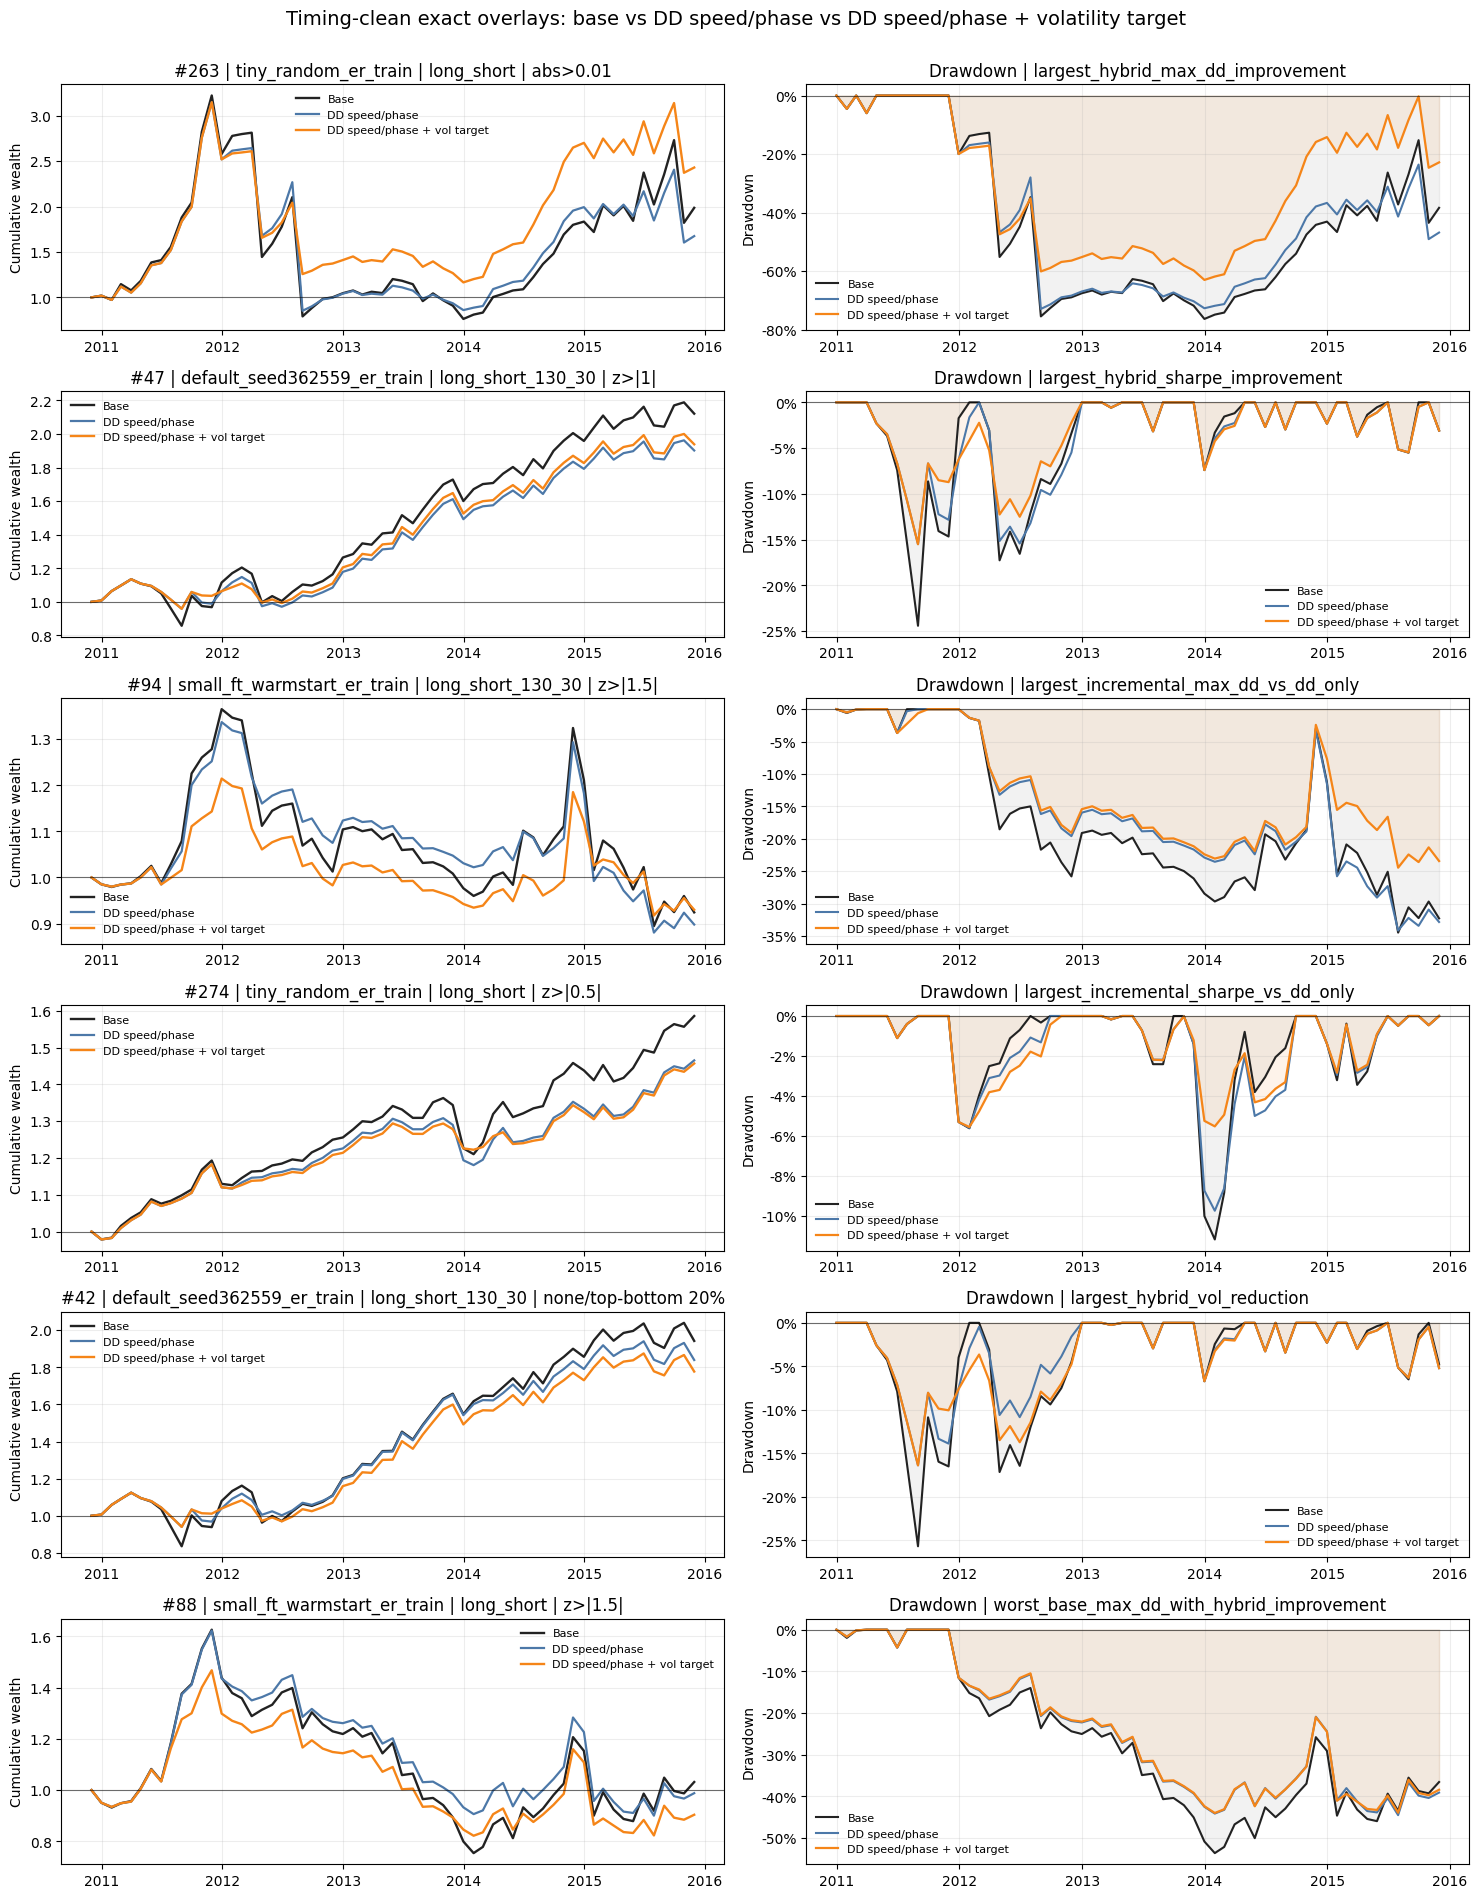

Saved figure: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/temporal_tabular_score_strategies/figures/validation_exact_scaled_cost_overlay_diverse_strategy_comparison_10bps.png


In [19]:
# Cell 17: Timing-clean example plots for exact scaled-cost overlays

EXACT_PLOT_N = 6

required_exact_plot_objects = [
    "exact_overlay_strategy_results",
    "exact_overlay_monthly_results",
    "drawdown_series_from_returns",
    "cumulative_wealth_with_start",
    "format_dd_phase_display",
]
missing_exact_plot_objects = [name for name in required_exact_plot_objects if name not in globals()]
if missing_exact_plot_objects:
    raise RuntimeError(f"Run Cell 16 first. Missing objects: {missing_exact_plot_objects}")

exact_dd_only_metrics = exact_overlay_strategy_results.loc[
    exact_overlay_strategy_results["overlay_method"].eq("dd_speed_phase_control"),
    [
        "risk_strategy_id",
        "overlay_annualized_return",
        "overlay_annualized_volatility",
        "overlay_sharpe",
        "overlay_average_drawdown",
        "overlay_max_drawdown",
    ],
].rename(
    columns={
        "overlay_annualized_return": "dd_only_annualized_return",
        "overlay_annualized_volatility": "dd_only_annualized_volatility",
        "overlay_sharpe": "dd_only_sharpe",
        "overlay_average_drawdown": "dd_only_average_drawdown",
        "overlay_max_drawdown": "dd_only_max_drawdown",
    }
)

exact_hybrid_plot_pool = exact_overlay_strategy_results.loc[
    exact_overlay_strategy_results["overlay_method"].eq("dd_speed_phase_vol_target")
].merge(exact_dd_only_metrics, on="risk_strategy_id", how="left", validate="one_to_one")
exact_hybrid_plot_pool["incremental_sharpe_vs_dd_only"] = exact_hybrid_plot_pool["overlay_sharpe"] - exact_hybrid_plot_pool["dd_only_sharpe"]
exact_hybrid_plot_pool["incremental_max_dd_vs_dd_only"] = exact_hybrid_plot_pool["overlay_max_drawdown"] - exact_hybrid_plot_pool["dd_only_max_drawdown"]
exact_hybrid_plot_pool["incremental_vol_reduction_vs_dd_only"] = exact_hybrid_plot_pool["dd_only_annualized_volatility"] - exact_hybrid_plot_pool["overlay_annualized_volatility"]


def select_exact_overlay_plot_strategies(pool: pd.DataFrame, n: int = EXACT_PLOT_N) -> pd.DataFrame:
    picks = []
    used_ids = set()
    used_shapes = set()
    selectors = [
        ("largest_hybrid_max_dd_improvement", pool.sort_values("delta_max_drawdown", ascending=False)),
        ("largest_hybrid_sharpe_improvement", pool.sort_values("delta_sharpe", ascending=False)),
        ("largest_incremental_max_dd_vs_dd_only", pool.sort_values("incremental_max_dd_vs_dd_only", ascending=False)),
        ("largest_incremental_sharpe_vs_dd_only", pool.sort_values("incremental_sharpe_vs_dd_only", ascending=False)),
        ("largest_hybrid_vol_reduction", pool.sort_values("delta_annualized_volatility", ascending=True)),
        ("worst_base_max_dd_with_hybrid_improvement", pool.loc[pool["delta_max_drawdown"].gt(0)].sort_values("base_max_drawdown", ascending=True)),
        ("highest_base_return_with_hybrid_mdd_improvement", pool.loc[pool["delta_max_drawdown"].gt(0)].sort_values("base_annualized_return", ascending=False)),
    ]
    for reason, ordered in selectors:
        if len(picks) >= n:
            break
        for _, row in ordered.iterrows():
            strategy_id = int(row["risk_strategy_id"])
            shape = (row["strategy_family"], row["score_type"], row["rule"], row["threshold_label"])
            if strategy_id in used_ids or shape in used_shapes:
                continue
            picked = row.copy()
            picked["selection_reason"] = reason
            picks.append(picked)
            used_ids.add(strategy_id)
            used_shapes.add(shape)
            break
    if len(picks) < n:
        fill = pool.sort_values(["delta_sharpe", "delta_max_drawdown", "base_annualized_return"], ascending=[False, False, False])
        for _, row in fill.iterrows():
            strategy_id = int(row["risk_strategy_id"])
            if strategy_id in used_ids:
                continue
            picked = row.copy()
            picked["selection_reason"] = "exact_overlay_fill"
            picks.append(picked)
            used_ids.add(strategy_id)
            if len(picks) >= n:
                break
    return pd.DataFrame(picks).head(n).reset_index(drop=True)


exact_selected_plot_strategies = select_exact_overlay_plot_strategies(exact_hybrid_plot_pool, EXACT_PLOT_N)
exact_selected_plot_strategies.to_csv(
    BACKTEST_DIR / f"validation_exact_scaled_cost_overlay_selected_plot_strategies_{int(EXACT_OVERLAY_COST_BPS)}bps.csv",
    index=False,
)

EXACT_SELECTED_COLUMNS = [
    "selection_reason",
    "risk_strategy_id",
    "strategy_family",
    "score_label",
    "rule",
    "threshold_label",
    "base_annualized_return",
    "dd_only_annualized_return",
    "overlay_annualized_return",
    "base_annualized_volatility",
    "dd_only_annualized_volatility",
    "overlay_annualized_volatility",
    "base_sharpe",
    "dd_only_sharpe",
    "overlay_sharpe",
    "base_max_drawdown",
    "dd_only_max_drawdown",
    "overlay_max_drawdown",
    "incremental_max_dd_vs_dd_only",
]
print("Timing-clean strategies used for base vs DD-speed/phase vs hybrid plots.")
display(
    format_dd_phase_display(
        exact_selected_plot_strategies[EXACT_SELECTED_COLUMNS],
        percent_cols=[
            "base_annualized_return",
            "dd_only_annualized_return",
            "overlay_annualized_return",
            "base_annualized_volatility",
            "dd_only_annualized_volatility",
            "overlay_annualized_volatility",
            "base_max_drawdown",
            "dd_only_max_drawdown",
            "overlay_max_drawdown",
            "incremental_max_dd_vs_dd_only",
        ],
        decimal_cols=["base_sharpe", "dd_only_sharpe", "overlay_sharpe"],
    )
)

if not exact_selected_plot_strategies.empty:
    n_plots = len(exact_selected_plot_strategies)
    fig, axes = plt.subplots(n_plots, 2, figsize=(15, 3.15 * n_plots), squeeze=False)
    for plot_idx, (_, spec) in enumerate(exact_selected_plot_strategies.iterrows()):
        strategy_id = int(spec["risk_strategy_id"])
        dd_only = exact_overlay_monthly_results.loc[
            exact_overlay_monthly_results["risk_strategy_id"].eq(strategy_id)
            & exact_overlay_monthly_results["overlay_method"].eq("dd_speed_phase_control")
        ].sort_values("month")
        hybrid = exact_overlay_monthly_results.loc[
            exact_overlay_monthly_results["risk_strategy_id"].eq(strategy_id)
            & exact_overlay_monthly_results["overlay_method"].eq("dd_speed_phase_vol_target")
        ].sort_values("month")
        plot_monthly = hybrid.merge(
            dd_only[["month", "overlay_net_return"]].rename(columns={"overlay_net_return": "dd_only_net_return"}),
            on="month",
            how="left",
            validate="one_to_one",
        )
        month_index = pd.to_datetime(plot_monthly["month"])
        base_wealth = cumulative_wealth_with_start(plot_monthly["net_return"], plot_monthly["month"])
        dd_only_wealth = cumulative_wealth_with_start(plot_monthly["dd_only_net_return"], plot_monthly["month"])
        hybrid_wealth = cumulative_wealth_with_start(plot_monthly["overlay_net_return"], plot_monthly["month"])
        base_dd = drawdown_series_from_returns(plot_monthly["net_return"])
        dd_only_dd = drawdown_series_from_returns(plot_monthly["dd_only_net_return"])
        hybrid_dd = drawdown_series_from_returns(plot_monthly["overlay_net_return"])

        title = f"#{strategy_id} | {spec['score_label']} | {spec['rule']} | {spec['threshold_label']}"
        ax_wealth = axes[plot_idx, 0]
        ax_wealth.plot(base_wealth.index, base_wealth.values, color="#222222", linewidth=1.7, label="Base")
        ax_wealth.plot(dd_only_wealth.index, dd_only_wealth.values, color="#4C78A8", linewidth=1.6, label="DD speed/phase")
        ax_wealth.plot(hybrid_wealth.index, hybrid_wealth.values, color="#F58518", linewidth=1.7, label="DD speed/phase + vol target")
        ax_wealth.axhline(1.0, color="black", linewidth=0.8, alpha=0.55)
        ax_wealth.set_title(title)
        ax_wealth.set_ylabel("Cumulative wealth")
        ax_wealth.grid(alpha=0.22)
        ax_wealth.legend(frameon=False, fontsize=8)

        ax_dd = axes[plot_idx, 1]
        ax_dd.plot(month_index, base_dd.values, color="#222222", linewidth=1.5, label="Base")
        ax_dd.plot(month_index, dd_only_dd.values, color="#4C78A8", linewidth=1.5, label="DD speed/phase")
        ax_dd.plot(month_index, hybrid_dd.values, color="#F58518", linewidth=1.6, label="DD speed/phase + vol target")
        ax_dd.axhline(0.0, color="black", linewidth=0.8, alpha=0.55)
        ax_dd.fill_between(month_index, base_dd.values, 0.0, color="#222222", alpha=0.06)
        ax_dd.fill_between(month_index, hybrid_dd.values, 0.0, color="#F58518", alpha=0.09)
        ax_dd.set_title(f"Drawdown | {spec['selection_reason']}")
        ax_dd.set_ylabel("Drawdown")
        ax_dd.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax_dd.grid(alpha=0.22)
        ax_dd.legend(frameon=False, fontsize=8)

    fig.suptitle("Timing-clean exact overlays: base vs DD speed/phase vs DD speed/phase + volatility target", y=1.002, fontsize=14)
    fig.tight_layout()
    exact_plot_path = FIGURE_DIR / f"validation_exact_scaled_cost_overlay_diverse_strategy_comparison_{int(EXACT_OVERLAY_COST_BPS)}bps.png"
    fig.savefig(exact_plot_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {exact_plot_path}")


Timing-clean target strategy: small_mlp_warmstart_er_train | long_short | abs>0.01 | 10 bps
OOS is the test split.


,split,series,annualized_return,annualized_volatility,sharpe,average_drawdown,max_drawdown,terminal_wealth
0,validation,Base,156.22%,69.00%,2.26,-9.60%,-53.23%,110.43
1,validation,DD speed/phase,137.02%,64.48%,2.13,-10.07%,-43.98%,74.80
2,validation,DD speed/phase + vol target,133.85%,63.97%,2.09,-10.31%,-44.80%,69.94
3,test,Base,146.94%,44.83%,3.28,-3.50%,-25.61%,3166.83
4,test,DD speed/phase,132.59%,43.52%,3.05,-3.79%,-25.61%,1856.96
5,test,DD speed/phase + vol target,121.85%,43.00%,2.83,-3.88%,-25.61%,1218.04


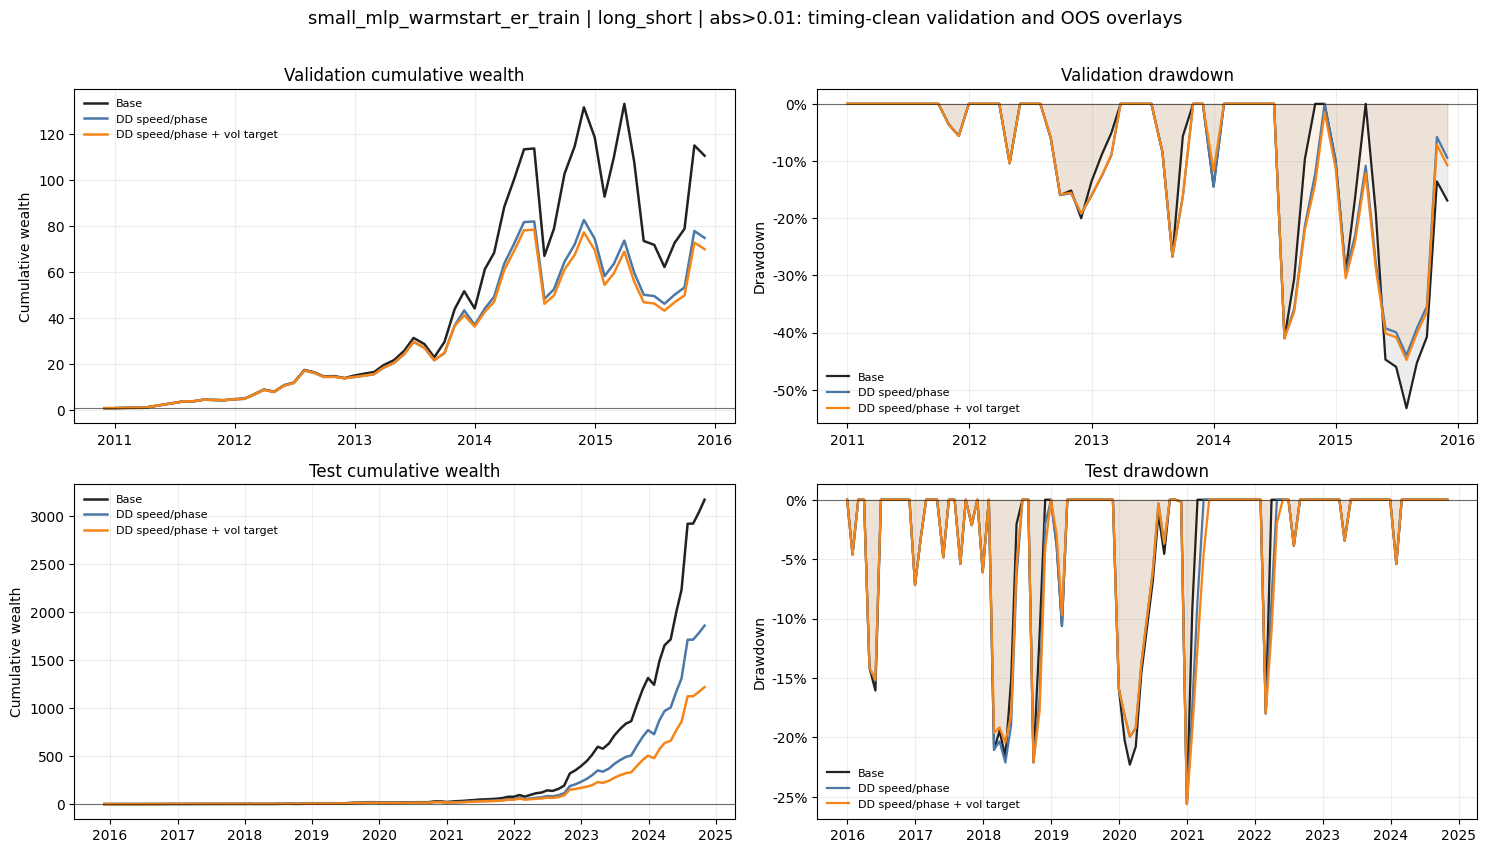

Saved figure: /home/aturin/ML/ML_For_Finance_Project-AxelTurinPlessia-362559-ClementMeddeb-346164/outputs/backtests/temporal_tabular_score_strategies/figures/validation_oos_exact_scaled_cost_overlays_small_mlp_warmstart_er_train_long_short_abs001_10bps.png


In [20]:
# Cell 18: Timing-clean validation and OOS plot for small_mlp_warmstart_er_train long-short abs>0.01

TARGET_SCORE_LABEL = "small_mlp_warmstart_er_train"
TARGET_RULE = "long_short"
TARGET_THRESHOLD_LABEL = "abs>0.01"
TARGET_STRATEGY_FAMILY = "absolute_or_none"
TARGET_SPLITS = ["validation", "test"]
TARGET_COST_BPS = EXACT_OVERLAY_COST_BPS

required_target_exact_objects = [
    "all_strategy_summary",
    "exact_scaled_overlay_for_strategy",
    "performance_metrics",
    "drawdown_series_from_returns",
    "cumulative_wealth_with_start",
    "format_dd_phase_display",
]
missing_target_exact_objects = [name for name in required_target_exact_objects if name not in globals()]
if missing_target_exact_objects:
    raise RuntimeError(f"Run Cell 16 first. Missing objects: {missing_target_exact_objects}")

target_matches = all_strategy_summary.loc[
    all_strategy_summary["split"].eq("validation")
    & all_strategy_summary["one_way_cost_bps"].eq(TARGET_COST_BPS)
    & all_strategy_summary["strategy_family"].eq(TARGET_STRATEGY_FAMILY)
    & all_strategy_summary["score_label"].eq(TARGET_SCORE_LABEL)
    & all_strategy_summary["rule"].eq(TARGET_RULE)
    & all_strategy_summary["threshold_label"].eq(TARGET_THRESHOLD_LABEL)
].copy()
if target_matches.empty:
    raise ValueError("Target strategy was not found in all_strategy_summary.")
target_spec = target_matches.iloc[0]

target_rows = []
target_monthly_by_split = {}
for target_split in TARGET_SPLITS:
    dd_only = exact_scaled_overlay_for_strategy(target_spec, method="dd_speed_phase_control", split=target_split)
    hybrid = exact_scaled_overlay_for_strategy(target_spec, method="dd_speed_phase_vol_target", split=target_split)
    target_monthly_by_split[target_split] = {"dd_only": dd_only, "hybrid": hybrid}
    for label, returns in [
        ("Base", hybrid["net_return"]),
        ("DD speed/phase", dd_only["overlay_net_return"]),
        ("DD speed/phase + vol target", hybrid["overlay_net_return"]),
    ]:
        target_rows.append({"split": target_split, "series": label, **performance_metrics(returns)})

target_exact_perf = pd.DataFrame(target_rows)
target_exact_perf.to_csv(BACKTEST_DIR / f"target_exact_scaled_cost_overlays_{TARGET_SCORE_LABEL}_{TARGET_RULE}_abs001_{int(TARGET_COST_BPS)}bps.csv", index=False)

target_display = target_exact_perf.copy()
for col in ["annualized_return", "annualized_volatility", "average_drawdown", "max_drawdown"]:
    target_display[col] = target_display[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "")
target_display["sharpe"] = target_display["sharpe"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
target_display["terminal_wealth"] = target_display["terminal_wealth"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
print(
    f"Timing-clean target strategy: {TARGET_SCORE_LABEL} | {TARGET_RULE} | {TARGET_THRESHOLD_LABEL} | "
    f"{TARGET_COST_BPS:.0f} bps"
)
print("OOS is the test split.")
display(target_display)

fig, axes = plt.subplots(len(TARGET_SPLITS), 2, figsize=(15, 4.2 * len(TARGET_SPLITS)), squeeze=False)
for row_idx, target_split in enumerate(TARGET_SPLITS):
    dd_only = target_monthly_by_split[target_split]["dd_only"]
    hybrid = target_monthly_by_split[target_split]["hybrid"]
    plot_monthly = hybrid.merge(
        dd_only[["month", "overlay_net_return"]].rename(columns={"overlay_net_return": "dd_only_net_return"}),
        on="month",
        how="left",
        validate="one_to_one",
    )
    month_index = pd.to_datetime(plot_monthly["month"])
    base_wealth = cumulative_wealth_with_start(plot_monthly["net_return"], plot_monthly["month"])
    dd_only_wealth = cumulative_wealth_with_start(plot_monthly["dd_only_net_return"], plot_monthly["month"])
    hybrid_wealth = cumulative_wealth_with_start(plot_monthly["overlay_net_return"], plot_monthly["month"])
    base_dd = drawdown_series_from_returns(plot_monthly["net_return"])
    dd_only_dd = drawdown_series_from_returns(plot_monthly["dd_only_net_return"])
    hybrid_dd = drawdown_series_from_returns(plot_monthly["overlay_net_return"])

    ax_wealth = axes[row_idx, 0]
    ax_wealth.plot(base_wealth.index, base_wealth.values, color="#222222", linewidth=1.8, label="Base")
    ax_wealth.plot(dd_only_wealth.index, dd_only_wealth.values, color="#4C78A8", linewidth=1.8, label="DD speed/phase")
    ax_wealth.plot(hybrid_wealth.index, hybrid_wealth.values, color="#F58518", linewidth=1.8, label="DD speed/phase + vol target")
    ax_wealth.axhline(1.0, color="black", linewidth=0.8, alpha=0.55)
    ax_wealth.set_title(f"{target_split.title()} cumulative wealth")
    ax_wealth.set_ylabel("Cumulative wealth")
    ax_wealth.grid(alpha=0.22)
    ax_wealth.legend(frameon=False, fontsize=8)

    ax_dd = axes[row_idx, 1]
    ax_dd.plot(month_index, base_dd.values, color="#222222", linewidth=1.6, label="Base")
    ax_dd.plot(month_index, dd_only_dd.values, color="#4C78A8", linewidth=1.6, label="DD speed/phase")
    ax_dd.plot(month_index, hybrid_dd.values, color="#F58518", linewidth=1.6, label="DD speed/phase + vol target")
    ax_dd.axhline(0.0, color="black", linewidth=0.8, alpha=0.55)
    ax_dd.fill_between(month_index, base_dd.values, 0.0, color="#222222", alpha=0.08)
    ax_dd.fill_between(month_index, hybrid_dd.values, 0.0, color="#F58518", alpha=0.10)
    ax_dd.set_title(f"{target_split.title()} drawdown")
    ax_dd.set_ylabel("Drawdown")
    ax_dd.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax_dd.grid(alpha=0.22)
    ax_dd.legend(frameon=False, fontsize=8)

fig.suptitle(
    f"{TARGET_SCORE_LABEL} | {TARGET_RULE} | {TARGET_THRESHOLD_LABEL}: timing-clean validation and OOS overlays",
    y=1.01,
    fontsize=13,
)
fig.tight_layout()
target_exact_plot_path = FIGURE_DIR / f"validation_oos_exact_scaled_cost_overlays_{TARGET_SCORE_LABEL}_{TARGET_RULE}_abs001_{int(TARGET_COST_BPS)}bps.png"
fig.savefig(target_exact_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved figure: {target_exact_plot_path}")
